# Shared latent space across mechanical datasets

Train one shared 2D autoencoder using one trajectory each from Reid, low-temperature de Pablo, and mixed-temperature de Pablo. Test whether unseen static structures share a p-ratio coordinate, whether their source family can be inferred from the initial latent, and how temperature appears in mixed-temperature latent trajectories. Coordinates, edge vectors, and edge lengths use the normalized reference-box convention; stiffness values pass through unchanged. This notebook intentionally contains no propagator or rollout.

In [1]:
%matplotlib inline
import hashlib
import json
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0, str(PROJECT_ROOT/'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import Normalize

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.experiment import ground_truth_p_ratio, run_latent_experiment, seed_everything
from lss.latent.training import encode_frame_latent
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device

apply_editorial_style()
PAPER_DPI = 180
PAPER_FIGSIZE = (5.4, 4.2)
PAPER_WIDE_FIGSIZE = (10.8, 4.2)
plt.rcParams.update({'figure.dpi': PAPER_DPI, 'savefig.dpi': 400})
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Configuration

In [2]:
SEED = 786
TRAIN_PER_SOURCE = 1
VAL_PER_SOURCE = 10
LATENT_DIM = 2
MAX_FRAME = 199
FRAME_STRIDE = 1

DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'de Pablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    'depablo_mixed_temp': {'label': 'de Pablo mixed-T', 'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'},
}
for spec in DATASETS.values(): assert spec['path'].exists(), spec['path']
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06_mixed_dataset_shared_latent_space_boxnorm'
OUTPUT.mkdir(parents=True, exist_ok=True)

AE_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96,
    'model': 'attention', 'batch_graphs': 32,
    'max_train_frames_per_sim': 200, 'val_frame_skip': 8, 'max_val_frames_per_sim': 200,
    'max_epochs': 80, 'patience': 8, 'lr': 1e-4, 'weight_decay': 1e-5,
    'node_feature_mode': 'normalized_delta', 'target_mode': 'normalized_delta',
    'coordinate_normalization': 'position_normalization',
    'edge_mode': 'compact_stored',
    'edge_feature_schema': 'compact_unique_edge_changes_v1',
}
CACHE_IDENTITY = {'seed': SEED, 'datasets': {key: str(value['path']) for key,value in DATASETS.items()}, 'train_per_source': TRAIN_PER_SOURCE, 'val_per_source': VAL_PER_SOURCE, 'normalized_box': '[-1,1]^2', 'original_reference_context': True, 'stiffness_passthrough': True, 'ae': AE_CONFIG}
CACHE_TAG = hashlib.sha1(json.dumps(CACHE_IDENTITY, sort_keys=True).encode()).hexdigest()[:12]
if not DATASETS:
    raise ValueError('Enable at least one entry in DATASETS.')
SOURCE_COUNT = len(DATASETS)
EXPERIMENT_LABEL = 'single-source 2D AE' if SOURCE_COUNT == 1 else f'shared {SOURCE_COUNT}-source 2D AE'
AE_CACHE = OUTPUT/f'position_normalized_{SOURCE_COUNT}source_{CACHE_TAG}.pt'
print({'device': str(DEVICE), 'cache': str(AE_CACHE), 'training_trajectories': TRAIN_PER_SOURCE*len(DATASETS), 'latent_dim': LATENT_DIM})

{'device': 'cuda', 'cache': '/home/alexz/Documents/course_project/notebooks/results/06_mixed_dataset_shared_latent_space_boxnorm/position_normalized_3source_e7e5a33f064d.pt', 'training_trajectories': 3, 'latent_dim': 2}


## Shared three-trajectory autoencoder

In [3]:
experiment_config = {
    'dataset_name': 'mixed_sources_shared', 'split_seed': SEED, 'split_stratify_temperature': False,
    'ae_config': {**AE_CONFIG, 'edge_feature_dim': 4},
    'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2,
    'frame_skip': 1, 'train_frame_start_order': 0,
    'early_stop_min_delta': 1e-5,
    'model_seed': SEED, 'repeat_idx': 1, 'should_rollout': False,
    'should_train_propagator': False, 'force_train': False, 'cache_path': str(AE_CACHE),
    'cache_require_matching_config': True,
}
mixture = [
    {'name': key, 'label': spec['label'], 'path': str(spec['path']), 'train_count': TRAIN_PER_SOURCE, 'val_count': VAL_PER_SOURCE}
    for key, spec in DATASETS.items()
]
active_source_label = ' + '.join(spec['label'] for spec in DATASETS.values())
source = {
    'dataset_name': 'mixed_sources_shared', 'source_name': active_source_label,
    'label': EXPERIMENT_LABEL, 'path': str(next(iter(DATASETS.values()))['path']), 'dataset_mixture': mixture,
}
seed_everything(SEED)
result = run_latent_experiment(source, experiment_config, device=DEVICE)
display(result['split_info'])

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/06_mixed_dataset_shared_latent_space_boxnorm/position_normalized_3source_e7e5a33f064d.pt


,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,1,1,10,91
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,1,1,10,189
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,1,1,10,289


## Held-out latent descriptors

In [4]:
frame_df, _, _, _ = framewise_latent_descriptor_sweep(result, device=DEVICE, frame_stride=FRAME_STRIDE, max_frames_per_sim=None)
SOURCE_LABELS = {key: spec['label'] for key, spec in DATASETS.items()}
SOURCE_MARKER_CYCLE = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', 'h']
SOURCE_COLOR_CYCLE = [PAPER_COLORS[name] for name in ['blue','red','green','purple','orange','sky','gold','slate']]
SOURCE_STYLES = {
    spec['label']: (key, SOURCE_MARKER_CYCLE[index % len(SOURCE_MARKER_CYCLE)])
    for index, (key, spec) in enumerate(DATASETS.items())
}
SOURCE_COLORS = {
    spec['label']: SOURCE_COLOR_CYCLE[index % len(SOURCE_COLOR_CYCLE)]
    for index, spec in enumerate(DATASETS.values())
}
frame_df['dataset'] = frame_df['source'].replace(SOURCE_LABELS)

descriptor_rows = []
for (split, sim_idx), trajectory in frame_df.sort_values(['split','sim_idx','frame_idx']).groupby(['split','sim_idx']):
    time = trajectory.frame_idx.to_numpy(float)
    temperature = float(trajectory.temperature.iloc[0]) if 'temperature' in trajectory and trajectory.temperature.notna().any() else np.nan
    row = {'split': split, 'sim_idx': int(sim_idx), 'source': trajectory.source.iloc[0], 'dataset': trajectory.dataset.iloc[0], 'temperature': temperature, 'final_p_ratio': float(trajectory.side_final_trajectory_p_ratio.iloc[0])}
    for coordinate in range(LATENT_DIM):
        values = trajectory[f'z{coordinate}'].to_numpy(float)
        row[f'z{coordinate}_initial'] = values[0]
        row[f'z{coordinate}_delta'] = values[-1]-values[0]
        slope, intercept = np.polyfit(time, values, 1)
        row[f'z{coordinate}_slope'] = slope
        row[f'z{coordinate}_std'] = np.nanstd(values)
        row[f'z{coordinate}_detrended_std'] = np.nanstd(values - (slope*time + intercept))
    descriptor_rows.append(row)
descriptor_df = pd.DataFrame(descriptor_rows).replace([np.inf,-np.inf],np.nan)
frame_df.to_csv(OUTPUT/'framewise_heldout_latents.csv', index=False)
descriptor_df.to_csv(OUTPUT/'network_latent_descriptors.csv', index=False)
display(descriptor_df.groupby(['split','dataset']).agg(networks=('sim_idx','count'), p_ratio_min=('final_p_ratio','min'), p_ratio_max=('final_p_ratio','max'), temperature_min=('temperature','min'), temperature_max=('temperature','max')).round(3))

networks  p_ratio_min  p_ratio_max  temperature_min  \
split dataset                                                                 
test  Reid                    91       -0.617        0.384              0.0   
      de Pablo low-T         189       -0.799        0.406              0.0   
      de Pablo mixed-T       289       -0.792        0.405              0.1   
val   Reid                    10       -0.406        0.379              0.0   
      de Pablo low-T          10       -0.518        0.369              0.0   
      de Pablo mixed-T        10       -0.522        0.370              0.1   

                        temperature_max  
split dataset                            
test  Reid                          0.0  
      de Pablo low-T                0.0  
      de Pablo mixed-T             30.0  
val   Reid                          0.0  
      de Pablo low-T                0.0  
      de Pablo mixed-T             30.0

## Graph-context attribution

In [5]:
from lss.latent.simulation import compact_edge_features, compact_reference_edge_features, frame_node_feature, reference_positions_for_model

ATTRIBUTION_SPLIT = 'train'
ATTRIBUTION_DATASET = next(iter(DATASETS))
ATTRIBUTION_NETWORK = 0
matching = [sim for sim in result[f'{ATTRIBUTION_SPLIT}_data'] if str(getattr(sim[0], 'source_name', '')) == ATTRIBUTION_DATASET]
sim = matching[ATTRIBUTION_NETWORK]
graph = sim[0]
model = result['ae'].eval()
params = result['params']
stats = result['normalizers']
ref_pos = reference_positions_for_model(graph, pos_dim=2, device=DEVICE).detach()
node_input = frame_node_feature(sim, 0, pos_dim=2, mode=params['node_feature_mode'], device=DEVICE)
node_input = ((node_input-stats['node_feature_mean'].to(DEVICE))/stats['node_feature_std'].to(DEVICE)).detach()
edge_index = graph.edge_index.to(DEVICE).long()
edge_input = compact_edge_features(graph, graph, pos_dim=2, device=DEVICE)
edge_input = ((edge_input-stats['edge_mean'].to(DEVICE))/stats['edge_std'].to(DEVICE)).detach()
ref_edge_input = compact_reference_edge_features(graph, pos_dim=2, device=DEVICE)
ref_edge_input = ((ref_edge_input-stats['ref_edge_mean'].to(DEVICE))/stats['ref_edge_std'].to(DEVICE)).detach()
batch = torch.zeros(len(ref_pos), dtype=torch.long, device=DEVICE)

def attributed_latent(position=ref_pos, reference_edges=ref_edge_input):
    with torch.no_grad():
        latent, _ = model.encode(node_input, position, edge_input, reference_edges, edge_index, batch)
    return latent[0]

# Graph-context attribution calculations and graph renderings are omitted; the shared encoder inputs above are reused below.

## Graph-context attribution by dataset

In [6]:
%%capture
def static_context_ablation(trajectory):
    reference = trajectory[0]
    position = reference_positions_for_model(reference, pos_dim=2, device=DEVICE).detach()
    nodes = frame_node_feature(trajectory, 0, pos_dim=2, mode=result['params']['node_feature_mode'], device=DEVICE)
    nodes = ((nodes-result['normalizers']['node_feature_mean'].to(DEVICE))/result['normalizers']['node_feature_std'].to(DEVICE)).detach()
    connections = reference.edge_index.to(DEVICE).long()
    evolving_edges = compact_edge_features(reference, reference, pos_dim=2, device=DEVICE)
    evolving_edges = ((evolving_edges-result['normalizers']['edge_mean'].to(DEVICE))/result['normalizers']['edge_std'].to(DEVICE)).detach()
    static_edges = compact_reference_edge_features(reference, pos_dim=2, device=DEVICE)
    static_edges = ((static_edges-result['normalizers']['ref_edge_mean'].to(DEVICE))/result['normalizers']['ref_edge_std'].to(DEVICE)).detach()
    graph_batch = torch.zeros(len(position), dtype=torch.long, device=DEVICE)

    def encode(position_input=position, edge_input=static_edges):
        with torch.no_grad():
            latent, _ = result['ae'].encode(nodes, position_input, evolving_edges, edge_input, connections, graph_batch)
        return latent[0]

    baseline = encode()
    edge_scores = torch.empty((connections.shape[1], LATENT_DIM), device=DEVICE)
    for edge_id in range(connections.shape[1]):
        ablated = static_edges.clone(); ablated[edge_id] = 0
        edge_scores[edge_id] = (encode(edge_input=ablated)-baseline).abs()
    node_scores = torch.empty((len(position), LATENT_DIM), device=DEVICE)
    for node_id in range(len(position)):
        ablated_position = position.clone(); ablated_position[node_id] = position.mean(dim=0)
        ablated_edges = static_edges.clone()
        ablated_edges[(connections[0] == node_id) | (connections[1] == node_id)] = 0
        node_scores[node_id] = (encode(ablated_position, ablated_edges)-baseline).abs()
    channel_scores = torch.empty((static_edges.shape[1], LATENT_DIM), device=DEVICE)
    for channel in range(static_edges.shape[1]):
        ablated = static_edges.clone(); ablated[:,channel] = 0
        channel_scores[channel] = (encode(edge_input=ablated)-baseline).abs()
    return {
        'position': position.cpu().numpy(), 'pairs': connections.T.cpu().numpy(),
        'node': node_scores.cpu().numpy(), 'edge': edge_scores.cpu().numpy(),
        'channel': channel_scores.cpu().numpy(), 'z': baseline.cpu().numpy(),
    }

dataset_attribution = {}
for source, specification in DATASETS.items():
    example = next(simulation for simulation in result['train_data'] if str(getattr(simulation[0], 'source_name', '')) == source)
    dataset_attribution[specification['label']] = static_context_ablation(example)

fig, axes = plt.subplots(len(dataset_attribution), 1, figsize=(3.8, 3.0*len(dataset_attribution)), squeeze=False, constrained_layout=True)
for row, (dataset, attribution) in enumerate(dataset_attribution.items()):
    for coordinate in [0]:
        ax = axes[row,coordinate]
        maximum = max(attribution['node'][:,coordinate].max(), attribution['edge'][:,coordinate].max(), 1e-12)
        for edge_id, (left,right) in enumerate(attribution['pairs']):
            relative = attribution['edge'][edge_id,coordinate]/maximum
            ax.plot(attribution['position'][[left,right],0], attribution['position'][[left,right],1], color=plt.cm.YlOrRd(relative), linewidth=.35+3.0*relative, alpha=.82, zorder=1)
        relative_nodes = attribution['node'][:,coordinate]/maximum
        ax.scatter(attribution['position'][:,0], attribution['position'][:,1], c=relative_nodes, cmap='YlOrRd', vmin=0, vmax=1, s=12+100*relative_nodes, edgecolor='white', linewidth=.3, zorder=2)
        if row == 0: ax.set_title(f'z{coordinate}')
        if coordinate == 0: ax.set_ylabel(dataset)
        ax.text(.98,.02,f'max |Δz| = {maximum:.3g}', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=PAPER_COLORS['ink'])
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.show()

channel_labels = ['bond dx','bond dy','bond length','stiffness']
channel_rows = []
for dataset, attribution in dataset_attribution.items():
    for coordinate in [0]:
        channel_rows.append({'dataset': dataset, 'latent': f'z{coordinate}', **dict(zip(channel_labels, attribution['channel'][:,coordinate]))})
display(pd.DataFrame(channel_rows).set_index(['dataset','latent']).round(4))

## Encoder inputs across the trajectory

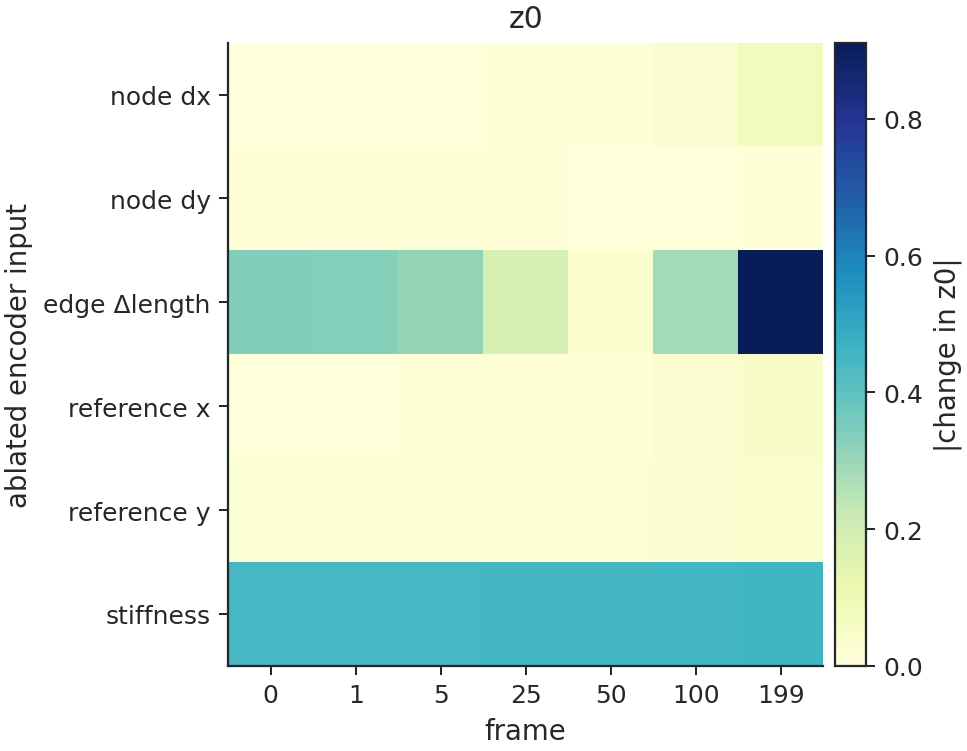

,z0_effect
input,
stiffness,0.4473
edge Δlength,0.3409
reference y,0.0213
node dx,0.0174
reference x,0.0139
node dy,0.0050


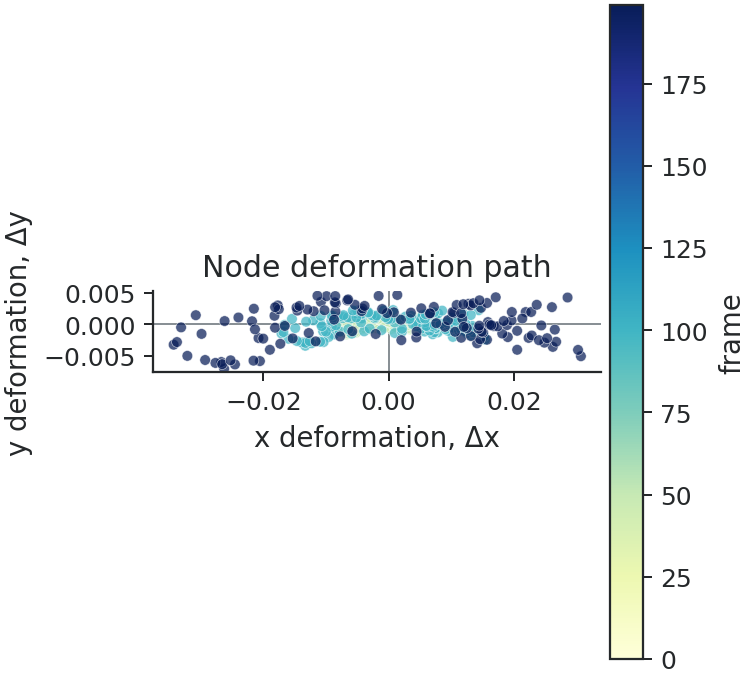

In [7]:
ATTRIBUTION_FRAMES = sorted(set([0, 1, 5, 25, 50, 100, len(sim)-1]))
INPUT_LABELS = ['node dx', 'node dy', 'edge Δlength', 'reference x', 'reference y', 'stiffness']
INPUT_SPECS = [('node', 0), ('node', 1), ('edge', 2), ('reference', 0), ('reference', 1), ('static_edge', 3)]
trajectory_effect = np.zeros((len(ATTRIBUTION_FRAMES), len(INPUT_LABELS), LATENT_DIM))
trajectory_latent = np.zeros((len(ATTRIBUTION_FRAMES), LATENT_DIM))

for frame_row, frame_index in enumerate(ATTRIBUTION_FRAMES):
    dynamic_node = frame_node_feature(sim, frame_index, pos_dim=2, mode=params['node_feature_mode'], device=DEVICE)
    dynamic_node = ((dynamic_node-stats['node_feature_mean'].to(DEVICE))/stats['node_feature_std'].to(DEVICE)).detach()
    dynamic_edge = compact_edge_features(graph, sim[frame_index], pos_dim=2, device=DEVICE)
    dynamic_edge = ((dynamic_edge-stats['edge_mean'].to(DEVICE))/stats['edge_std'].to(DEVICE)).detach()

    def encode_inputs(nodes=dynamic_node, edges=dynamic_edge, position=ref_pos, reference_edges=ref_edge_input):
        with torch.no_grad():
            latent, _ = model.encode(nodes, position, edges, reference_edges, edge_index, batch)
        return latent[0]

    baseline = encode_inputs()
    trajectory_latent[frame_row] = baseline.detach().cpu().numpy()
    for input_row, (kind, channel) in enumerate(INPUT_SPECS):
        if kind == 'node':
            ablated = dynamic_node.clone(); ablated[:, channel] = 0
            changed = encode_inputs(nodes=ablated)
        elif kind == 'edge':
            ablated = dynamic_edge.clone(); ablated[:, channel] = 0
            changed = encode_inputs(edges=ablated)
        elif kind == 'reference':
            ablated = ref_pos.clone(); ablated[:, channel] = ablated[:, channel].mean()
            changed = encode_inputs(position=ablated)
        else:
            ablated = ref_edge_input.clone(); ablated[:, channel] = 0
            changed = encode_inputs(reference_edges=ablated)
        trajectory_effect[frame_row, input_row] = (changed-baseline).abs().cpu().numpy()

fig, ax = plt.subplots(figsize=(5.4, 4.2), constrained_layout=True)
shared_max = max(trajectory_effect[:,:,0].max(), 1e-12)
for coordinate in [0]:
    image = ax.imshow(trajectory_effect[:,:,coordinate].T, cmap='YlGnBu', vmin=0, vmax=shared_max, aspect='auto')
    ax.set(xticks=range(len(ATTRIBUTION_FRAMES)), xticklabels=ATTRIBUTION_FRAMES, yticks=range(len(INPUT_LABELS)), yticklabels=INPUT_LABELS)
    ax.set_title(f'z{coordinate}'); ax.set_xlabel('frame'); ax.grid(False, which='both')
ax.set_ylabel('ablated encoder input')
fig.colorbar(image, ax=ax, label='|change in z0|', pad=.02)
plt.show()

trajectory_attribution = pd.DataFrame([
    {'frame': frame, 'input': label, 'z0_effect': trajectory_effect[frame_row,input_row,0]}
    for frame_row, frame in enumerate(ATTRIBUTION_FRAMES) for input_row, label in enumerate(INPUT_LABELS)
])
display(trajectory_attribution.groupby('input')[['z0_effect']].mean().sort_values('z0_effect', ascending=False).round(4))

# Node deformation path: horizontal Δx versus vertical Δy at the same sampled frames.
fig, ax = plt.subplots(figsize=(4.2, 3.8), constrained_layout=True)
frame_norm = Normalize(vmin=min(ATTRIBUTION_FRAMES), vmax=max(ATTRIBUTION_FRAMES))
for frame_index in ATTRIBUTION_FRAMES:
    deformation = (sim[frame_index].x[:, :2] - sim[0].x[:, :2]).detach().cpu().numpy()
    ax.scatter(deformation[:, 0], deformation[:, 1], c=np.full(len(deformation), frame_index), cmap='YlGnBu', norm=frame_norm, s=18, alpha=.72, linewidth=.25, edgecolor='white')
ax.axhline(0, color=PAPER_COLORS['slate'], linewidth=.6, zorder=0)
ax.axvline(0, color=PAPER_COLORS['slate'], linewidth=.6, zorder=0)
ax.set(xlabel='x deformation, Δx', ylabel='y deformation, Δy', title='Node deformation path')
ax.set_aspect('equal'); ax.grid(False)
sm = plt.cm.ScalarMappable(norm=frame_norm, cmap='YlGnBu'); sm.set_array([])
fig.colorbar(sm, ax=ax, label='frame', pad=.02)
plt.show()

## Trajectory attribution by dataset

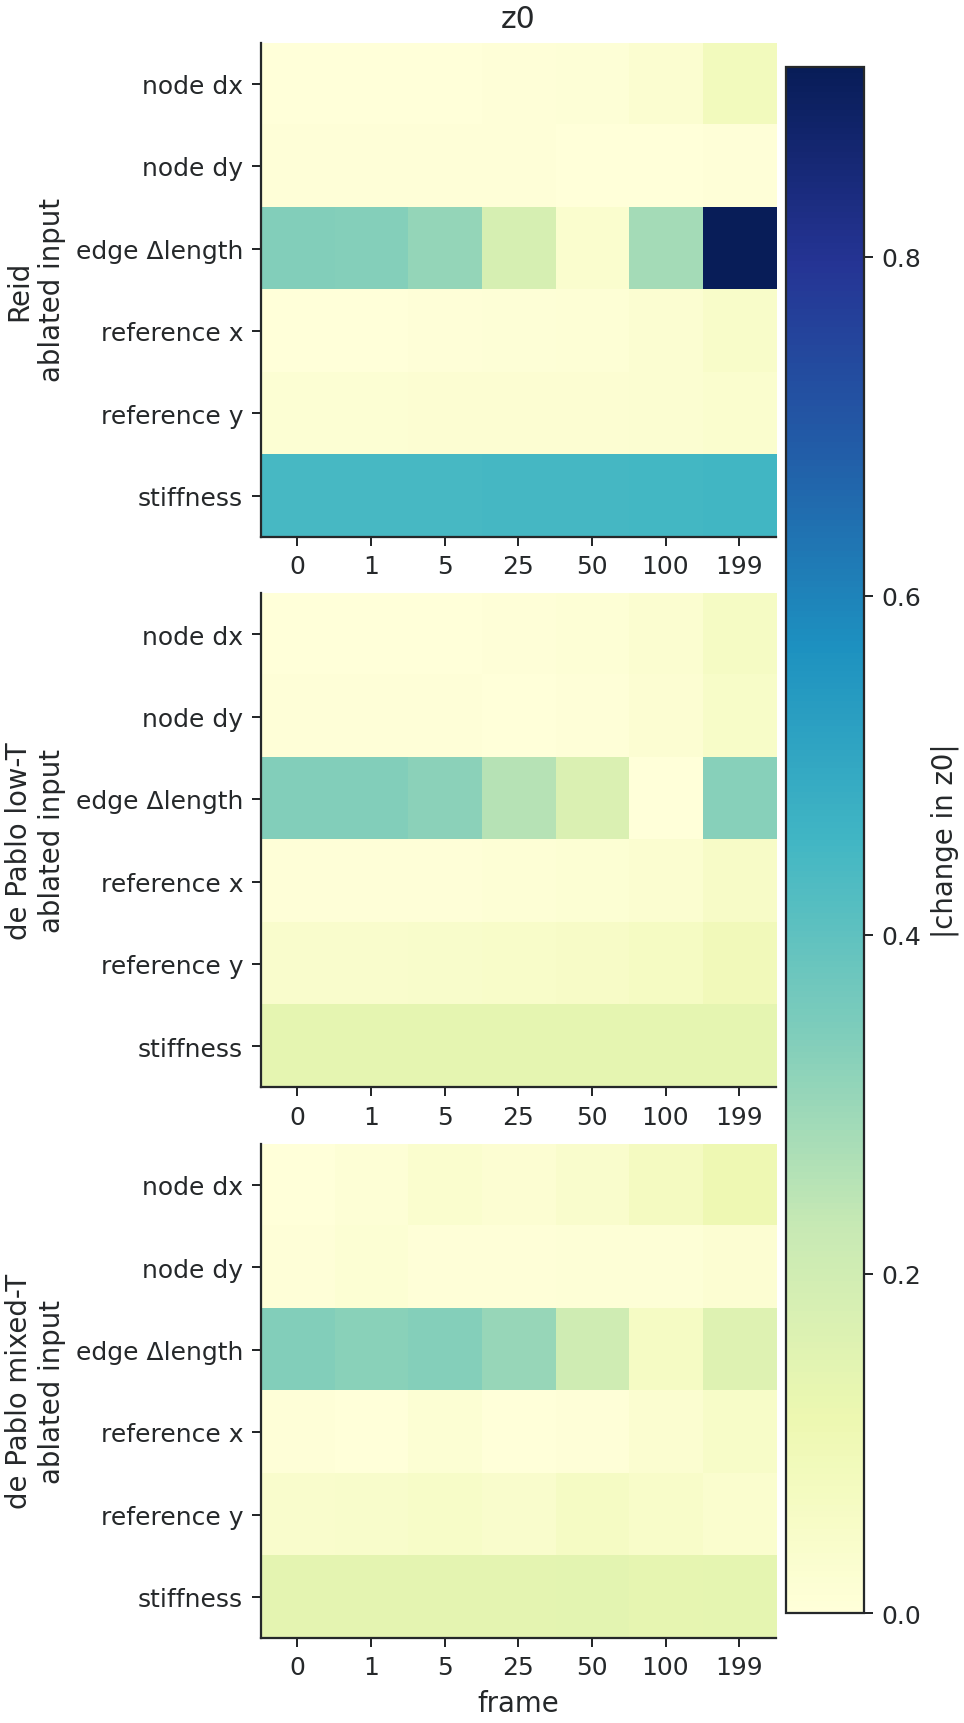

z0_effect
dataset          input                  
Reid             edge Δlength     0.3409
                 node dx          0.0174
                 node dy          0.0050
                 reference x      0.0139
                 reference y      0.0213
                 stiffness        0.4473
de Pablo low-T   edge Δlength     0.2495
                 node dx          0.0149
                 node dy          0.0134
                 reference x      0.0174
                 reference y      0.0518
                 stiffness        0.1374
de Pablo mixed-T edge Δlength     0.2457
                 node dx          0.0396
                 node dy          0.0104
                 reference x      0.0154
                 reference y      0.0424
                 stiffness        0.1396

In [8]:
def trajectory_input_ablation(trajectory):
    reference = trajectory[0]
    frames = sorted(set([0, 1, 5, 25, 50, 100, len(trajectory)-1]))
    position = reference_positions_for_model(reference, pos_dim=2, device=DEVICE).detach()
    connections = reference.edge_index.to(DEVICE).long()
    static_edges = compact_reference_edge_features(reference, pos_dim=2, device=DEVICE)
    static_edges = ((static_edges-result['normalizers']['ref_edge_mean'].to(DEVICE))/result['normalizers']['ref_edge_std'].to(DEVICE)).detach()
    graph_batch = torch.zeros(len(position), dtype=torch.long, device=DEVICE)
    effects = np.zeros((len(frames), len(INPUT_LABELS), LATENT_DIM))

    for frame_row, frame_index in enumerate(frames):
        nodes = frame_node_feature(trajectory, frame_index, pos_dim=2, mode=result['params']['node_feature_mode'], device=DEVICE)
        nodes = ((nodes-result['normalizers']['node_feature_mean'].to(DEVICE))/result['normalizers']['node_feature_std'].to(DEVICE)).detach()
        evolving_edges = compact_edge_features(reference, trajectory[frame_index], pos_dim=2, device=DEVICE)
        evolving_edges = ((evolving_edges-result['normalizers']['edge_mean'].to(DEVICE))/result['normalizers']['edge_std'].to(DEVICE)).detach()

        def encode(node_values=nodes, edge_values=evolving_edges, reference_positions=position, reference_edges=static_edges):
            with torch.no_grad():
                latent, _ = result['ae'].encode(node_values, reference_positions, edge_values, reference_edges, connections, graph_batch)
            return latent[0]

        baseline = encode()
        for input_row, (kind, channel) in enumerate(INPUT_SPECS):
            if kind == 'node':
                ablated = nodes.clone(); ablated[:,channel] = 0
                changed = encode(node_values=ablated)
            elif kind == 'edge':
                ablated = evolving_edges.clone(); ablated[:,channel] = 0
                changed = encode(edge_values=ablated)
            elif kind == 'reference':
                ablated = position.clone(); ablated[:,channel] = ablated[:,channel].mean()
                changed = encode(reference_positions=ablated)
            else:
                ablated = static_edges.clone(); ablated[:,channel] = 0
                changed = encode(reference_edges=ablated)
            effects[frame_row,input_row] = (changed-baseline).abs().cpu().numpy()
    return frames, effects

dataset_trajectory_attribution = {}
for source, specification in DATASETS.items():
    example = next(simulation for simulation in result['train_data'] if str(getattr(simulation[0], 'source_name', '')) == source)
    dataset_trajectory_attribution[specification['label']] = trajectory_input_ablation(example)

shared_max = max(max(effect[:,:,0].max() for _,effect in dataset_trajectory_attribution.values()), 1e-12)
fig, axes = plt.subplots(len(dataset_trajectory_attribution), 1, figsize=(5.4, 3.2*len(dataset_trajectory_attribution)), squeeze=False, sharey=True, constrained_layout=True)
for row, (dataset, (frames, effects)) in enumerate(dataset_trajectory_attribution.items()):
    for coordinate in [0]:
        ax = axes[row,coordinate]
        image = ax.imshow(effects[:,:,coordinate].T, cmap='YlGnBu', vmin=0, vmax=shared_max, aspect='auto')
        ax.set(xticks=range(len(frames)), xticklabels=frames, yticks=range(len(INPUT_LABELS)), yticklabels=INPUT_LABELS)
        if row == 0: ax.set_title(f'z{coordinate}')
        if coordinate == 0: ax.set_ylabel(f'{dataset}\nablated input')
        if row == len(dataset_trajectory_attribution)-1: ax.set_xlabel('frame')
        ax.grid(False, which='both')
fig.colorbar(image, ax=axes, label='|change in z0|', pad=.02)
plt.show()

dataset_trajectory_rows = []
for dataset, (frames, effects) in dataset_trajectory_attribution.items():
    for frame_row, frame in enumerate(frames):
        for input_row, label in enumerate(INPUT_LABELS):
            dataset_trajectory_rows.append({'dataset':dataset, 'frame':frame, 'input':label, 'z0_effect':effects[frame_row,input_row,0]})
dataset_trajectory_effects = pd.DataFrame(dataset_trajectory_rows)
display(dataset_trajectory_effects.groupby(['dataset','input'])[['z0_effect']].mean().round(4))

## Latent–mechanics correlation heatmaps

Paper-facing summary using an equal-weight mean of the absolute correlations measured separately within each held-out dataset. This avoids correlations caused only by offsets between dataset families while treating either relationship direction as equally informative. Initial latent state and latent slope test static versus dynamical encoding; the mechanical columns retain only p-ratio, directional deformation, and non-affine motion.

Mean absolute within-dataset correlations: latent trajectory summaries versus global mechanical descriptors.


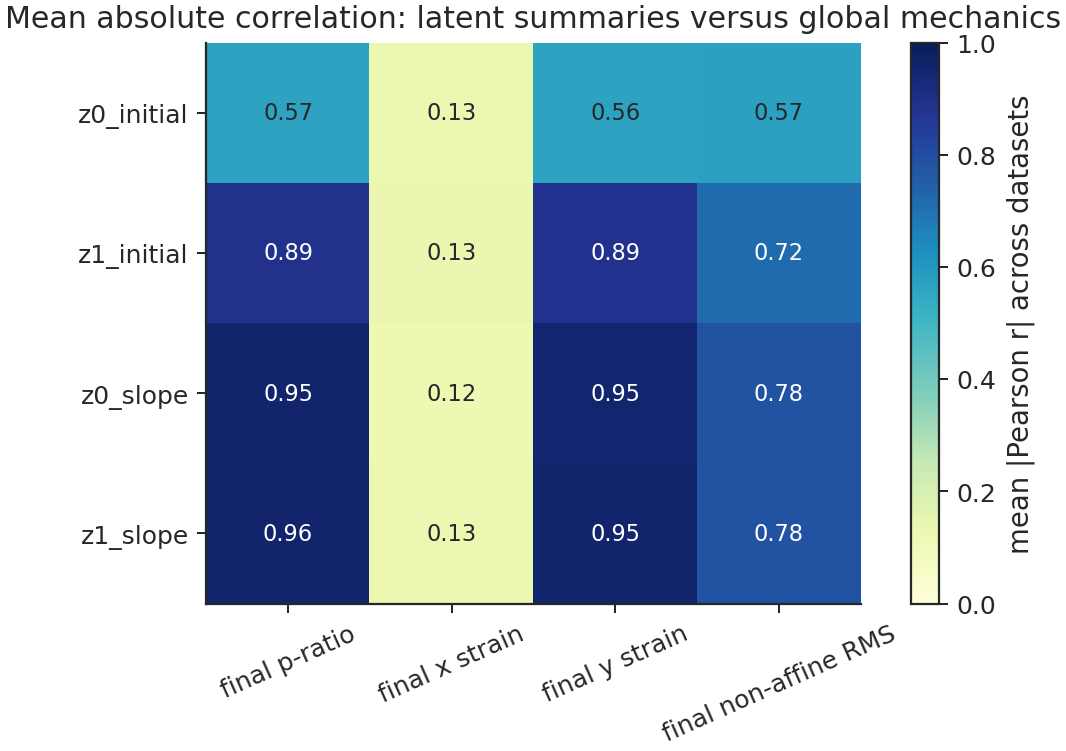

Equal-weight mean across datasets of absolute within-trajectory latent–mechanics correlations.


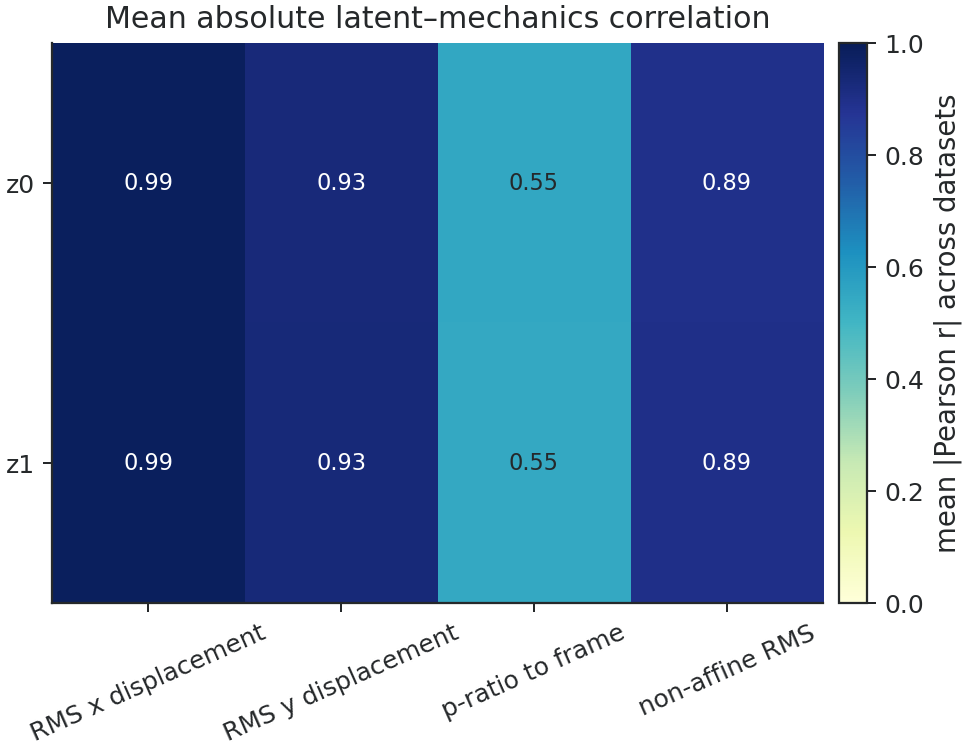

,dataset,latent_descriptor,global_descriptor,pearson_r,absolute_pearson_r,n_networks
0,Reid,z0_initial,final_p_ratio,0.875,0.875,91
1,de Pablo low-T,z0_initial,final_p_ratio,0.431,0.431,189
2,de Pablo mixed-T,z0_initial,final_p_ratio,0.391,0.391,289
3,Reid,z0_initial,side_strain_x,0.276,0.276,91
4,de Pablo low-T,z0_initial,side_strain_x,-0.060,0.060,189
5,de Pablo mixed-T,z0_initial,side_strain_x,0.051,0.051,289
6,Reid,z0_initial,side_strain_y,0.878,0.878,91
7,de Pablo low-T,z0_initial,side_strain_y,0.429,0.429,189
8,de Pablo mixed-T,z0_initial,side_strain_y,0.381,0.381,289
9,Reid,z0_initial,nonaffine_rms,-0.883,0.883,91


,dataset,latent_coordinate,frame_descriptor,mean_abs_r,std_abs_r,n_trajectories
0,Reid,z0,nonaffine_rms,1.000,0.000,91
1,Reid,z0,rms_dx,1.000,0.000,91
2,Reid,z0,rms_dy,0.999,0.001,91
3,Reid,z0,side_cumulative_p_ratio,0.646,0.236,91
4,Reid,z1,nonaffine_rms,1.000,0.000,91
5,Reid,z1,rms_dx,1.000,0.000,91
6,Reid,z1,rms_dy,1.000,0.001,91
7,Reid,z1,side_cumulative_p_ratio,0.645,0.236,91
8,de Pablo low-T,z0,nonaffine_rms,1.000,0.000,189
9,de Pablo low-T,z0,rms_dx,1.000,0.000,189


In [9]:
DESCRIPTORS = [f'z{i}_{kind}' for kind in ['initial','delta','slope'] for i in range(LATENT_DIM)]
PAPER_DESCRIPTORS = [f'z{i}_{kind}' for kind in ['initial','slope'] for i in range(LATENT_DIM)]
DATASET_LABELS = [spec['label'] for spec in DATASETS.values()]

def correlation_heatmap(table, *, title, colorbar_label='Pearson r'):
    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
    image = ax.imshow(table, cmap='YlGnBu', vmin=0, vmax=1, aspect='auto')
    ax.set(xticks=range(table.shape[1]), xticklabels=table.columns, yticks=range(table.shape[0]), yticklabels=table.index)
    ax.tick_params(axis='x', rotation=24)
    ax.grid(False, which='both')
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = table.iloc[row, col]
            ax.text(col, row, '—' if not np.isfinite(value) else f'{value:.2f}', ha='center', va='center', color='white' if np.isfinite(value) and abs(value) > .58 else PAPER_COLORS['ink'], fontsize=9)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=colorbar_label, pad=.02)
    plt.show()

# Between-network correlations: latent trajectory summaries versus global outcomes.
final_frame = (frame_df.sort_values('frame_idx').groupby(['split','sim_idx'], as_index=False).tail(1))
GLOBAL_DESCRIPTORS = {
    'final_p_ratio': 'final p-ratio',
    'side_strain_x': 'final x strain', 'side_strain_y': 'final y strain',
    'nonaffine_rms': 'final non-affine RMS',
}
network_data = descriptor_df.merge(final_frame[['split','sim_idx', *[name for name in GLOBAL_DESCRIPTORS if name not in descriptor_df.columns]]], on=['split','sim_idx'], how='left')
network_data = network_data.query("split == 'test'").copy()
test_descriptors = network_data
network_rows = []
network_table = pd.DataFrame(index=PAPER_DESCRIPTORS, columns=GLOBAL_DESCRIPTORS.values(), dtype=float)
for latent_descriptor in PAPER_DESCRIPTORS:
    for global_descriptor, display_name in GLOBAL_DESCRIPTORS.items():
        dataset_rs = []
        for dataset in DATASET_LABELS:
            group = network_data[network_data.dataset.eq(dataset)]
            values = group[[latent_descriptor, global_descriptor]].replace([np.inf,-np.inf],np.nan).dropna()
            r = pearson_r(values[latent_descriptor], values[global_descriptor]) if len(values) >= 3 and values[latent_descriptor].std() > 0 and values[global_descriptor].std() > 0 else np.nan
            dataset_rs.append(abs(r))
            network_rows.append({'dataset': dataset, 'latent_descriptor': latent_descriptor, 'global_descriptor': global_descriptor, 'pearson_r': r, 'absolute_pearson_r': abs(r), 'n_networks': len(values)})
        network_table.loc[latent_descriptor, display_name] = np.nanmean(dataset_rs) if np.isfinite(dataset_rs).any() else np.nan
network_correlations = pd.DataFrame(network_rows)
network_correlations.to_csv(OUTPUT/'network_latent_global_descriptor_correlations.csv', index=False)
correlations = network_correlations
print('Mean absolute within-dataset correlations: latent trajectory summaries versus global mechanical descriptors.')
correlation_heatmap(network_table, title='Mean absolute correlation: latent summaries versus global mechanics', colorbar_label='mean |Pearson r| across datasets')

# Within-network correlations are computed separately per trajectory, then averaged.
FRAME_DESCRIPTORS = {
    'rms_dx': 'RMS x displacement', 'rms_dy': 'RMS y displacement',
    'side_cumulative_p_ratio': 'p-ratio to frame',
    'nonaffine_rms': 'non-affine RMS',
}
trajectory_rows = []
for (dataset, sim_idx), trajectory in frame_df.query("split == 'test'").groupby(['dataset','sim_idx']):
    for latent_coordinate in [f'z{i}' for i in range(LATENT_DIM)]:
        for frame_descriptor in FRAME_DESCRIPTORS:
            values = trajectory[[latent_coordinate, frame_descriptor]].replace([np.inf,-np.inf],np.nan).dropna()
            r = pearson_r(values[latent_coordinate], values[frame_descriptor]) if len(values) >= 4 and values[latent_coordinate].std() > 0 and values[frame_descriptor].std() > 0 else np.nan
            trajectory_rows.append({'dataset': dataset, 'sim_idx': int(sim_idx), 'latent_coordinate': latent_coordinate, 'frame_descriptor': frame_descriptor, 'pearson_r': r, 'absolute_pearson_r': abs(r), 'n_frames': len(values)})
trajectory_correlations = pd.DataFrame(trajectory_rows)
trajectory_correlations.to_csv(OUTPUT/'within_trajectory_latent_frame_correlations.csv', index=False)
dataset_trajectory_correlations = trajectory_correlations.groupby(['dataset','latent_coordinate','frame_descriptor']).agg(mean_abs_r=('absolute_pearson_r','mean'), std_abs_r=('absolute_pearson_r','std'), n_trajectories=('absolute_pearson_r','count')).reset_index()
frame_table = dataset_trajectory_correlations.pivot_table(index='latent_coordinate', columns='frame_descriptor', values='mean_abs_r', aggfunc='mean').reindex(index=[f'z{i}' for i in range(LATENT_DIM)], columns=FRAME_DESCRIPTORS).rename(columns=FRAME_DESCRIPTORS)
print('Equal-weight mean across datasets of absolute within-trajectory latent–mechanics correlations.')
correlation_heatmap(frame_table, title='Mean absolute latent–mechanics correlation', colorbar_label='mean |Pearson r| across datasets')
display(network_correlations.round(3), dataset_trajectory_correlations.round(3))

## Raw initial latent coordinates

Raw initial latent coordinates versus final p-ratio on held-out networks.


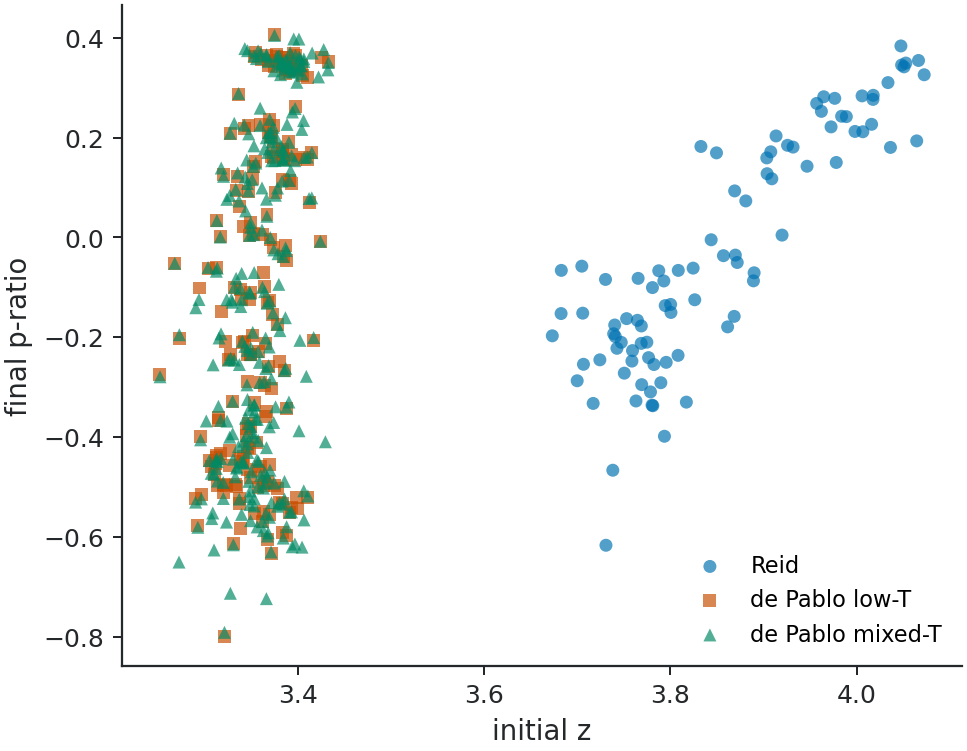

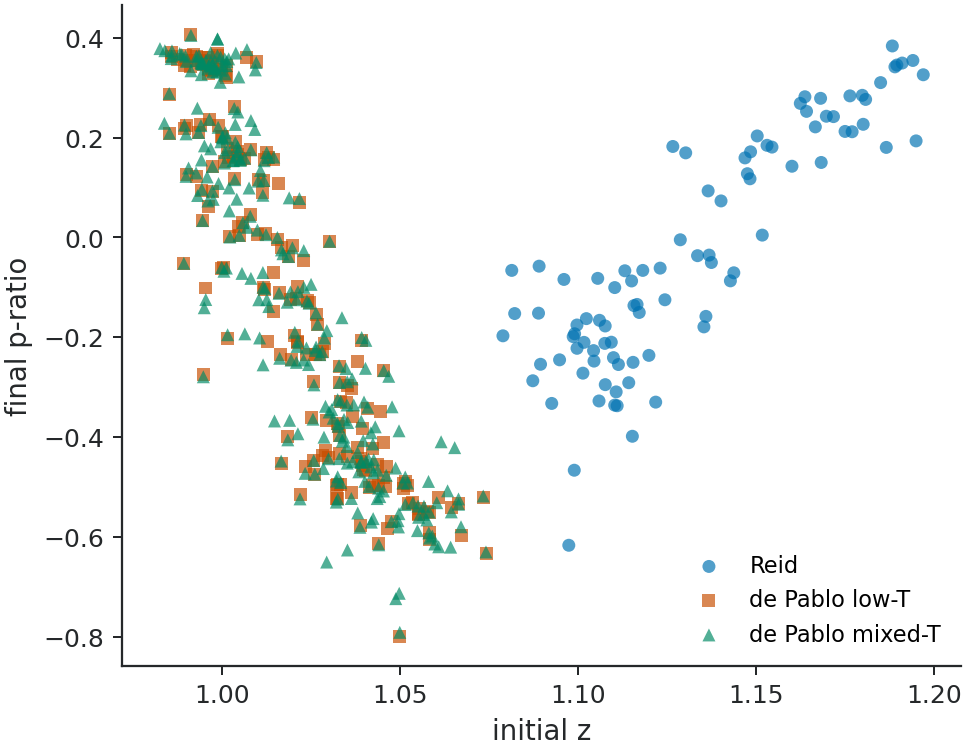

Raw z0-z1 plane using every encoded frame from held-out networks; colour denotes final p-ratio.


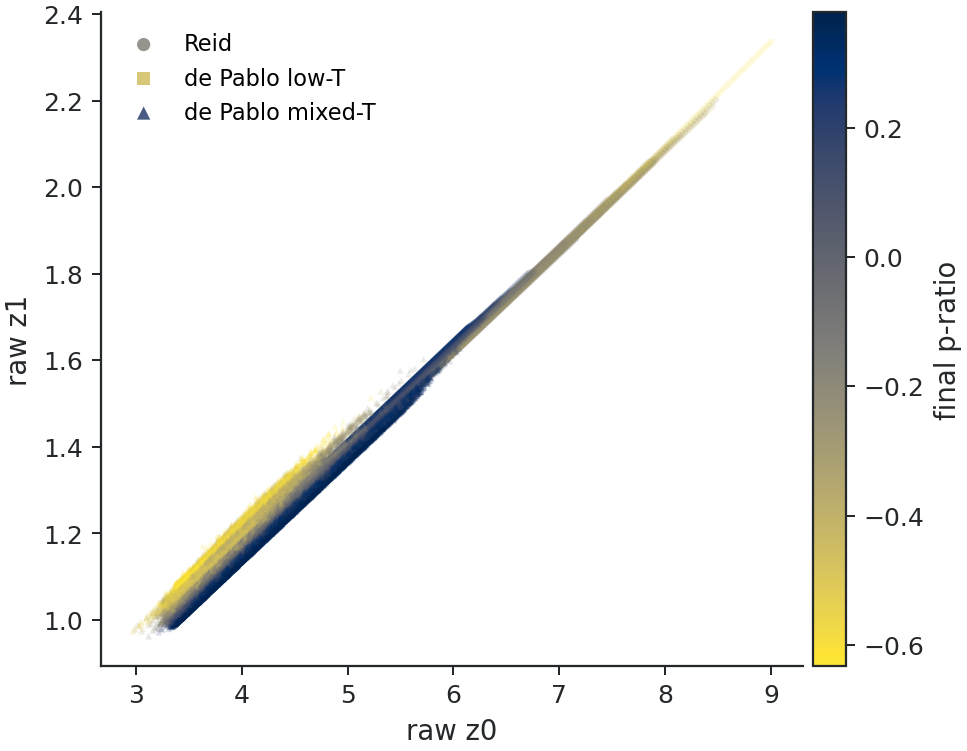

In [10]:
print('Raw initial latent coordinates versus final p-ratio on held-out networks.')
for latent_index in range(LATENT_DIM):
    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
    coordinate = f'z{latent_index}_initial'
    for dataset, group in test_descriptors.groupby('dataset', sort=False):
        key, marker = SOURCE_STYLES[dataset]
        values = group[[coordinate, 'final_p_ratio']].dropna()
        ax.scatter(values[coordinate], values.final_p_ratio, s=27, alpha=.68,
                   marker=marker, color=SOURCE_COLORS[dataset],
                   edgecolor='none', label=dataset)
    style_axes(ax, xlabel=f'initial z',
               ylabel='final p-ratio', legend=True)
    plt.show()

print('Raw z0-z1 plane using every encoded frame from held-out networks; colour denotes final p-ratio.')
all_test_frames = frame_df[frame_df.split.eq('test')].replace([np.inf, -np.inf], np.nan).dropna(subset=['z0', 'z1', 'side_final_trajectory_p_ratio'])
all_frame_norm = Normalize(vmin=all_test_frames.side_final_trajectory_p_ratio.quantile(.01), vmax=all_test_frames.side_final_trajectory_p_ratio.quantile(.99))
all_frame_cmap = plt.get_cmap('cividis_r')
fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
for dataset, group in all_test_frames.groupby('dataset', sort=False):
    _, marker = SOURCE_STYLES[dataset]
    ax.scatter(group.z0, group.z1, c=group.side_final_trajectory_p_ratio,
               cmap=all_frame_cmap, norm=all_frame_norm, marker=marker,
               s=7, alpha=.16, linewidth=0, rasterized=True, label=dataset)
style_axes(ax, xlabel='raw z0', ylabel='raw z1', legend=True)
for handle in ax.get_legend().legend_handles:
    handle.set_alpha(.85); handle.set_sizes([28])
fig.colorbar(plt.cm.ScalarMappable(norm=all_frame_norm, cmap=all_frame_cmap), ax=ax, label='final p-ratio', pad=.015)
plt.show()

## Held-out latent trajectories

Held-out z0 trajectories: colour denotes final p-ratio and line style denotes dataset. The right column enlarges the initial segment of the same trajectories.


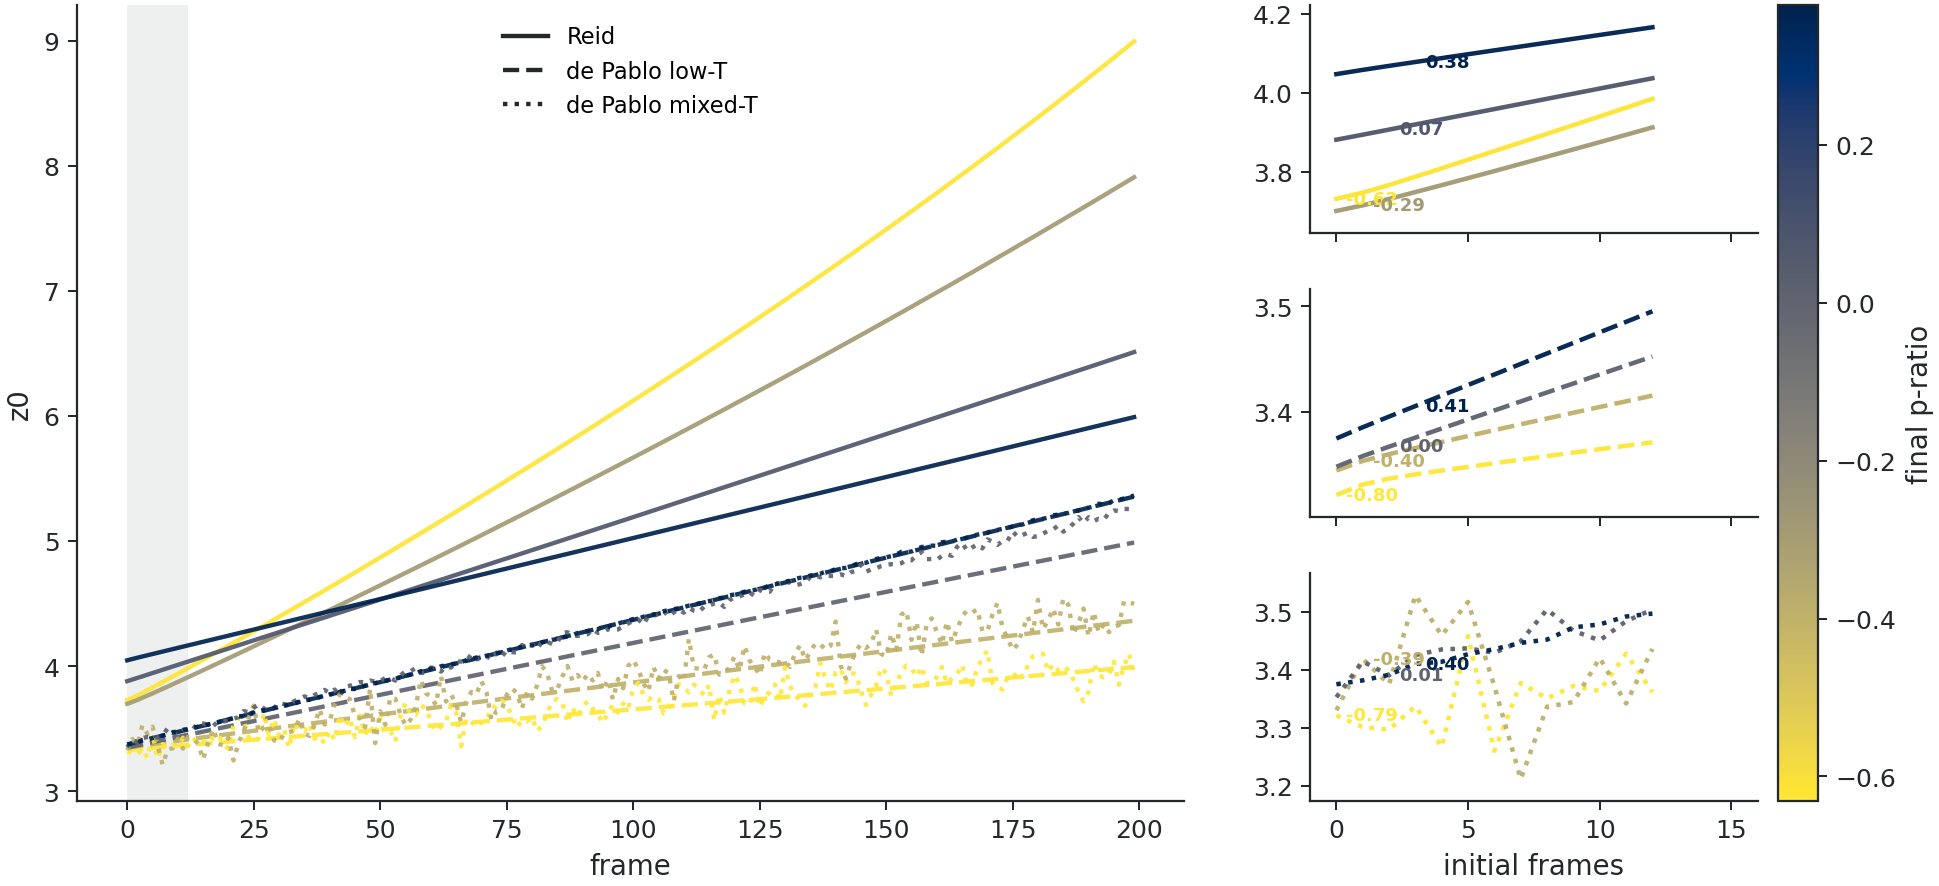

In [11]:
print('Held-out z0 trajectories: colour denotes final p-ratio and line style denotes dataset. The right column enlarges the initial segment of the same trajectories.')
line_style_cycle = ['-', '--', ':', '-.']
line_styles = {dataset: line_style_cycle[index % len(line_style_cycle)] for index, dataset in enumerate(DATASET_LABELS)}
plot_values = test_descriptors.final_p_ratio.replace([np.inf,-np.inf],np.nan).dropna()
norm = Normalize(vmin=plot_values.quantile(.01), vmax=plot_values.quantile(.99))
cmap = plt.get_cmap('cividis_r')
INITIAL_ZOOM_FRAME = 12

trajectory_figsize = (PAPER_WIDE_FIGSIZE[0], max(PAPER_WIDE_FIGSIZE[1], 1.65*len(DATASET_LABELS)))
fig = plt.figure(figsize=trajectory_figsize, constrained_layout=True)
grid = fig.add_gridspec(len(DATASET_LABELS), 2, width_ratios=[4.7, 1.9], hspace=.08, wspace=.07)
ax = fig.add_subplot(grid[:, 0])
zoom_axes = [fig.add_subplot(grid[row, 1]) for row in range(len(DATASET_LABELS))]
selected_rows = []
selected_trajectories = []

for dataset in DATASET_LABELS:
    networks = test_descriptors[test_descriptors.dataset.eq(dataset)].sort_values('final_p_ratio')
    target_values = np.linspace(networks.final_p_ratio.min(), networks.final_p_ratio.max(), min(4, len(networks)))
    available = networks.copy(); selected_indices = []
    for target_value in target_values:
        selected_index = (available.final_p_ratio-target_value).abs().idxmin()
        selected_indices.append(selected_index); available = available.drop(selected_index)
    selected = networks.loc[selected_indices].sort_values('final_p_ratio')
    for rank, (_, network) in enumerate(selected.iterrows(), start=1):
        trajectory = frame_df[
            (frame_df.split.eq('test'))
            & (frame_df.dataset.eq(dataset))
            & (frame_df.sim_idx.eq(network.sim_idx))
        ].sort_values('frame_idx')
        color = cmap(norm(network.final_p_ratio))
        ax.plot(
            trajectory.frame_idx, trajectory.z0,
            color=color, linestyle=line_styles[dataset], lw=1.75, alpha=.92,
        )
        selected_trajectories.append({
            'dataset': dataset, 'rank': rank,
            'final_p_ratio': float(network.final_p_ratio),
            'trajectory': trajectory, 'color': color,
        })
        selected_rows.append({
            'dataset': dataset, 'rank': rank,
            'sim_idx': int(network.sim_idx),
            'final_p_ratio': float(network.final_p_ratio),
            'initial_z0': float(trajectory.z0.iloc[0]),
        })

# The shaded interval is reproduced in the three dataset-specific zoom panels.
ax.axvspan(0, INITIAL_ZOOM_FRAME, color=PAPER_COLORS['slate'], alpha=.10, lw=0)
for dataset in DATASET_LABELS:
    ax.plot([], [], color=PAPER_COLORS['ink'], linestyle=line_styles[dataset], lw=1.75, label=dataset)
style_axes(ax, xlabel='frame', ylabel='z0', legend=True)

for zoom_ax, dataset in zip(zoom_axes, DATASET_LABELS):
    entries = [entry for entry in selected_trajectories if entry['dataset'] == dataset]
    initial_values = []
    for entry in entries:
        initial = entry['trajectory'][entry['trajectory'].frame_idx.le(INITIAL_ZOOM_FRAME)]
        initial_values.extend(initial.z0.to_list())
        zoom_ax.plot(
            initial.frame_idx, initial.z0,
            color=entry['color'], linestyle=line_styles[dataset], lw=1.8, alpha=.96,
        )
        label_point = initial.iloc[min(entry['rank']-1, len(initial)-1)]
        zoom_ax.annotate(
            f"{entry['final_p_ratio']:.2f}",
            xy=(float(label_point.frame_idx), float(label_point.z0)),
            xytext=(4, 0), textcoords='offset points',
            ha='left', va='center', fontsize=7.2,
            color=entry['color'], fontweight='semibold',
        )
    if initial_values:
        low, high = min(initial_values), max(initial_values)
        pad = .12*max(high-low, 1e-6)
        zoom_ax.set_ylim(low-pad, high+pad)
    zoom_ax.set_xlim(-1, INITIAL_ZOOM_FRAME+4)
    style_axes(
        zoom_ax,
        xlabel='initial frames' if zoom_ax is zoom_axes[-1] else '',
        ylabel='', legend=False,
    )
    if zoom_ax is not zoom_axes[-1]:
        zoom_ax.tick_params(axis='x', labelbottom=False)

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=[ax, *zoom_axes], label='final p-ratio', pad=.012, fraction=.035,
)
selected_z0_trajectories = pd.DataFrame(selected_rows)
selected_z0_trajectories.to_csv(OUTPUT/'heldout_z0_trajectory_selection.csv', index=False)
plt.show()


## Shared held-out p-ratio probe

Shared linear p-ratio readout fitted on validation networks and evaluated once on held-out networks.


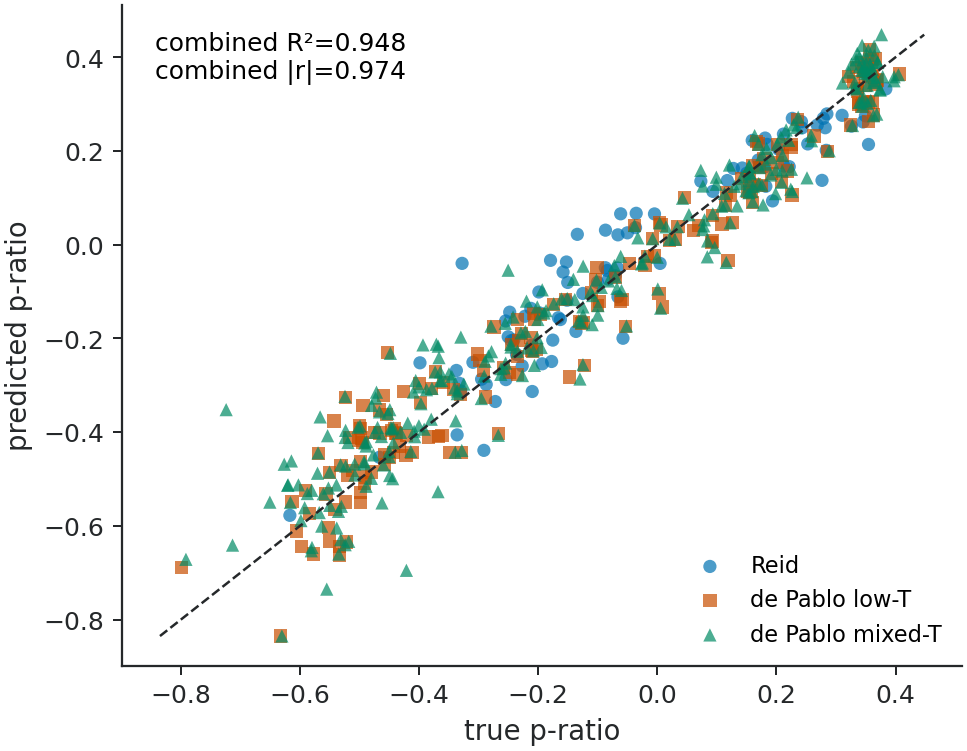

,method,evaluation_group,test_r2,pearson_r,n_networks
0,shared latent readout,combined,0.948,0.974,569
1,shared latent readout,Reid,0.898,0.949,91
2,shared latent readout,de Pablo low-T,0.960,0.980,189
3,shared latent readout,de Pablo mixed-T,0.947,0.974,289
4,source identity only,combined,0.008,0.096,569
5,source identity only,Reid,-0.024,NaN,91
6,source identity only,de Pablo low-T,-0.002,NaN,189
7,source identity only,de Pablo mixed-T,-0.000,NaN,289


Held-out p-ratio R² by latent information available to one shared readout.


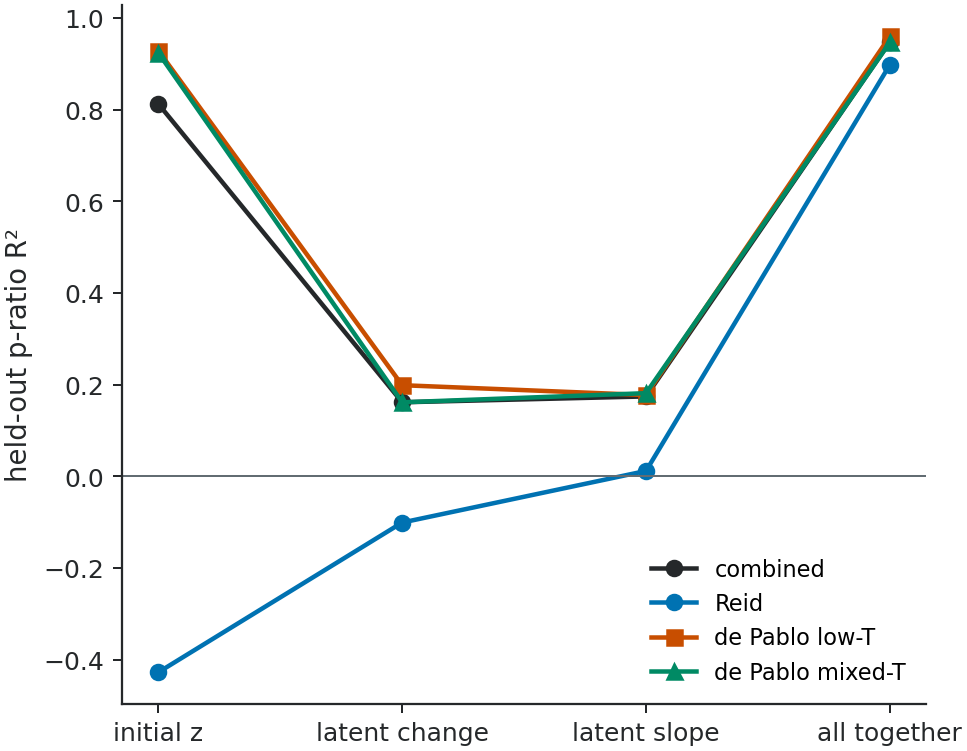

,feature_set,evaluation_group,test_r2,pearson_r,n_networks
0,initial z only,combined,0.813,0.914,569
1,initial z only,Reid,-0.427,-0.847,91
2,initial z only,de Pablo low-T,0.929,0.987,189
3,initial z only,de Pablo mixed-T,0.924,0.983,289
4,latent change only,combined,0.162,0.441,569
5,latent change only,Reid,-0.101,-0.069,91
6,latent change only,de Pablo low-T,0.199,0.694,189
7,latent change only,de Pablo mixed-T,0.162,0.517,289
8,latent slope only,combined,0.175,0.465,569
9,latent slope only,Reid,0.012,0.269,91


In [12]:
PROBE_FEATURES = DESCRIPTORS
def fit_ridge(train, test, features, ridge=1e-4):
    train = train[features+['final_p_ratio']].dropna(); test = test[features+['final_p_ratio','dataset','sim_idx']].dropna()
    x_train = train[features].to_numpy(float); y_train = train.final_p_ratio.to_numpy(float)
    mean, std = x_train.mean(0), x_train.std(0).clip(min=1e-12)
    x_train = (x_train-mean)/std; x_test = (test[features].to_numpy(float)-mean)/std
    design = np.column_stack([np.ones(len(x_train)),x_train]); penalty=np.eye(design.shape[1]); penalty[0,0]=0
    weights=np.linalg.solve(design.T@design+ridge*penalty,design.T@y_train)
    output=test[['dataset','sim_idx','final_p_ratio']].copy(); output['predicted_p_ratio']=np.column_stack([np.ones(len(x_test)),x_test])@weights
    return output

val = descriptor_df.query("split == 'val'"); test = descriptor_df.query("split == 'test'")
probe_predictions = fit_ridge(val, test, PROBE_FEATURES)
probe_rows=[]
for label, group in [('combined',probe_predictions), *[(dataset,probe_predictions[probe_predictions.dataset.eq(dataset)]) for dataset in DATASET_LABELS]]:
    probe_rows.append({'method':'shared latent readout','evaluation_group':label,'test_r2':r2_score(group.final_p_ratio,group.predicted_p_ratio),'pearson_r':pearson_r(group.final_p_ratio,group.predicted_p_ratio),'n_networks':len(group)})
source_means=val.groupby('dataset').final_p_ratio.mean()
source_baseline=test[['dataset','sim_idx','final_p_ratio']].copy(); source_baseline['predicted_p_ratio']=source_baseline.dataset.map(source_means)
for label,group in [('combined',source_baseline), *[(dataset,source_baseline[source_baseline.dataset.eq(dataset)]) for dataset in DATASET_LABELS]]:
    probe_rows.append({'method':'source identity only','evaluation_group':label,'test_r2':r2_score(group.final_p_ratio,group.predicted_p_ratio),'pearson_r':pearson_r(group.final_p_ratio,group.predicted_p_ratio),'n_networks':len(group)})
probe_scores=pd.DataFrame(probe_rows); probe_scores.to_csv(OUTPUT/'shared_probe_scores.csv',index=False); probe_predictions.to_csv(OUTPUT/'shared_probe_predictions.csv',index=False); source_baseline.to_csv(OUTPUT/'source_only_baseline_predictions.csv',index=False)
print('Shared linear p-ratio readout fitted on validation networks and evaluated once on held-out networks.')
fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
for dataset, group in probe_predictions.groupby('dataset'):
    key, marker = SOURCE_STYLES[dataset]
    ax.scatter(group.final_p_ratio,group.predicted_p_ratio,s=28,alpha=.7,marker=marker,color=SOURCE_COLORS[dataset],edgecolor='none',label=dataset)
limits=np.r_[probe_predictions.final_p_ratio,probe_predictions.predicted_p_ratio]; lo,hi=np.nanmin(limits),np.nanmax(limits)
ax.plot([lo,hi],[lo,hi],'--',color=PAPER_COLORS['ink'],lw=1)
combined=probe_scores.query("evaluation_group == 'combined' and method == 'shared latent readout'").iloc[0]
ax.text(.04,.96,f"combined R²={combined.test_r2:.3f}\ncombined |r|={abs(combined.pearson_r):.3f}",transform=ax.transAxes,ha='left',va='top')
style_axes(ax,xlabel='true p-ratio',ylabel='predicted p-ratio',legend=True)
plt.show(); display(probe_scores.round(3))

# Separate what is available at the static initial state from information extracted from the trajectory.
PROBE_FEATURE_SETS = {
    'initial z only': ['z0_initial', 'z1_initial'],
    'latent change only': ['z0_delta', 'z1_delta'],
    'latent slope only': ['z0_slope', 'z1_slope'],
    'all descriptors': DESCRIPTORS,
}
feature_set_rows = []
for feature_set, features in PROBE_FEATURE_SETS.items():
    predictions = fit_ridge(val, test, features)
    groups = [('combined', predictions)] + [
        (dataset, predictions[predictions.dataset.eq(dataset)])
        for dataset in DATASET_LABELS
    ]
    for evaluation_group, group in groups:
        feature_set_rows.append({
            'feature_set': feature_set, 'evaluation_group': evaluation_group,
            'test_r2': r2_score(group.final_p_ratio, group.predicted_p_ratio),
            'pearson_r': pearson_r(group.final_p_ratio, group.predicted_p_ratio),
            'n_networks': len(group),
        })
feature_set_scores = pd.DataFrame(feature_set_rows)
feature_set_scores.to_csv(OUTPUT/'shared_probe_feature_set_scores.csv', index=False)
print('Held-out p-ratio R² by latent information available to one shared readout.')
fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
plot_styles = {'combined': (PAPER_COLORS['ink'], 'o')}
plot_styles.update({dataset: (SOURCE_COLORS[dataset], marker) for dataset, (_, marker) in SOURCE_STYLES.items()})
x = np.arange(len(PROBE_FEATURE_SETS))
for evaluation_group, (color, marker) in plot_styles.items():
    group = feature_set_scores[feature_set_scores.evaluation_group.eq(evaluation_group)].set_index('feature_set').loc[list(PROBE_FEATURE_SETS)]
    ax.plot(x, group.test_r2, color=color, marker=marker, lw=1.8, ms=6, label=evaluation_group)
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
ax.set_xticks(x, ['initial z', 'latent change', 'latent slope', 'all together'])
style_axes(ax, xlabel='', ylabel='held-out p-ratio R²', legend=True)
plt.show()
display(feature_set_scores.round(3))

## One-frame nonlinear predictor trained on three networks

/tmp/ipykernel_4007034/2266605098.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_x = torch.as_tensor(three_example_train[['z0_initial','z1_initial']].to_numpy(float), dtype=torch.float32, device=DEVICE)


Single-frame p-ratio prediction from one shared nonlinear readout trained on exactly three networks.


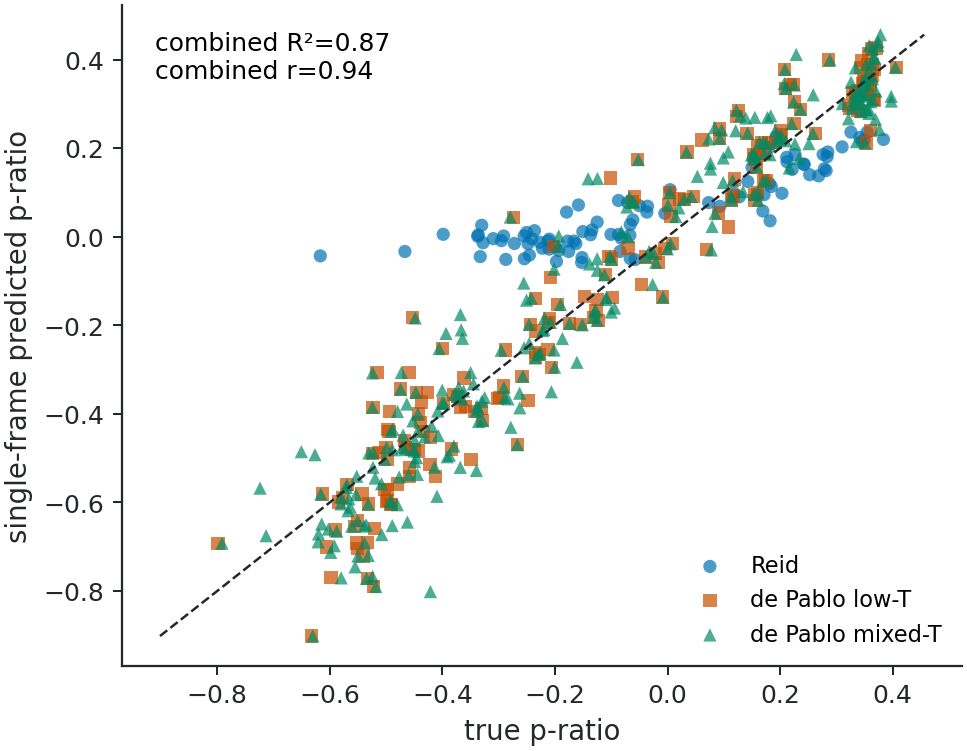

,sim_idx,source,dataset,z0_initial,z1_initial,final_p_ratio
0,0,reid,Reid,3.939,1.156,0.130
1,1,depablo_low_temp,de Pablo low-T,3.388,0.995,0.344
2,2,depablo_mixed_temp,de Pablo mixed-T,3.369,1.029,-0.248


,evaluation_group,test_r2,pearson_r,n_networks
0,combined,0.871,0.942,569
1,Reid,0.376,0.887,91
2,de Pablo low-T,0.921,0.967,189
3,de Pablo mixed-T,0.911,0.963,289


In [13]:
# Strict test: one labelled training trajectory per source and only its frame-0 latent is supplied.
three_example_rows = []
with torch.no_grad():
    for sim_idx, sim in enumerate(result['train_data']):
        source_name = str(getattr(sim[0], 'source_name', 'unknown'))
        z = encode_frame_latent(
            result['ae'], sim, 0, pos_dim=2,
            node_feature_mode=result['params']['node_feature_mode'],
            normalizers=result['normalizers'], device=DEVICE,
        ).detach().cpu().numpy()
        three_example_rows.append({
            'sim_idx': sim_idx, 'source': source_name,
            'dataset': SOURCE_LABELS.get(source_name, source_name),
            'z0_initial': float(z[0]), 'z1_initial': float(z[1]),
            'final_p_ratio': ground_truth_p_ratio(sim, -1, dataset_name=source_name, cfg=experiment_config),
        })
three_example_train = pd.DataFrame(three_example_rows)
assert len(three_example_train) == TRAIN_PER_SOURCE * len(DATASETS)

class StaticPratioMLP(torch.nn.Module):
    def __init__(self, hidden_size=8):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, hidden_size), torch.nn.GELU(),
            torch.nn.Linear(hidden_size, 1),
        )
    def forward(self, z): return self.net(z).squeeze(-1)

seed_everything(SEED + 17)
train_x = torch.as_tensor(three_example_train[['z0_initial','z1_initial']].to_numpy(float), dtype=torch.float32, device=DEVICE)
train_y = torch.as_tensor(three_example_train.final_p_ratio.to_numpy(float), dtype=torch.float32, device=DEVICE)
static_z_mean = train_x.mean(0); static_z_std = train_x.std(0, unbiased=False).clamp_min(1e-6)
static_y_mean = train_y.mean(); static_y_std = train_y.std(unbiased=False).clamp_min(1e-6)
static_mlp = StaticPratioMLP(hidden_size=8).to(DEVICE)
optimizer = torch.optim.AdamW(static_mlp.parameters(), lr=5e-3, weight_decay=1e-2)
for epoch in range(1500):
    optimizer.zero_grad(set_to_none=True)
    prediction = static_mlp((train_x-static_z_mean)/static_z_std)
    loss = torch.nn.functional.mse_loss(prediction, (train_y-static_y_mean)/static_y_std)
    loss.backward(); optimizer.step()

static_mlp.eval()
three_example_test = test_descriptors[['dataset','sim_idx','z0_initial','z1_initial','final_p_ratio']].dropna().copy()
test_x = torch.as_tensor(three_example_test[['z0_initial','z1_initial']].to_numpy(float), dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    predicted = static_mlp((test_x-static_z_mean)/static_z_std)*static_y_std + static_y_mean
three_example_test['predicted_p_ratio'] = predicted.cpu().numpy()
three_example_rows = []
for label, group in [('combined',three_example_test), *[(dataset,three_example_test[three_example_test.dataset.eq(dataset)]) for dataset in DATASET_LABELS]]:
    three_example_rows.append({'evaluation_group': label, 'test_r2': r2_score(group.final_p_ratio, group.predicted_p_ratio), 'pearson_r': pearson_r(group.final_p_ratio, group.predicted_p_ratio), 'n_networks': len(group)})
three_example_scores = pd.DataFrame(three_example_rows)
three_example_train.to_csv(OUTPUT/'three_example_static_mlp_training_points.csv', index=False)
three_example_test.to_csv(OUTPUT/'three_example_static_mlp_predictions.csv', index=False)
three_example_scores.to_csv(OUTPUT/'three_example_static_mlp_scores.csv', index=False)
torch.save({'model_state_dict': {k:v.detach().cpu() for k,v in static_mlp.state_dict().items()}, 'z_mean': static_z_mean.cpu(), 'z_std': static_z_std.cpu(), 'y_mean': static_y_mean.cpu(), 'y_std': static_y_std.cpu(), 'hidden_size': 8, 'training_networks': len(three_example_train)}, OUTPUT/'active_source_static_mlp.pt')
print('Single-frame p-ratio prediction from one shared nonlinear readout trained on exactly three networks.')
fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
for dataset, group in three_example_test.groupby('dataset', sort=False):
    key, marker = SOURCE_STYLES[dataset]
    ax.scatter(group.final_p_ratio, group.predicted_p_ratio, s=28, alpha=.7, marker=marker, color=SOURCE_COLORS[dataset], edgecolor='none', label=dataset)
limits=np.r_[three_example_test.final_p_ratio,three_example_test.predicted_p_ratio]; lo,hi=np.nanmin(limits),np.nanmax(limits)
ax.plot([lo,hi],[lo,hi],'--',color=PAPER_COLORS['ink'],lw=1)
combined_three = three_example_scores.query("evaluation_group == 'combined'").iloc[0]
ax.text(.04,.96,f"combined R²={combined_three.test_r2:.2f}\ncombined r={combined_three.pearson_r:.2f}", transform=ax.transAxes, ha='left', va='top')
style_axes(ax,xlabel='true p-ratio',ylabel='single-frame predicted p-ratio',legend=True)
plt.show(); display(three_example_train.round(3)); display(three_example_scores.round(3))

## Static family inference and p-ratio prediction

Static-only prediction: family inferred from initial latent, followed by its calibrated p-ratio readout.


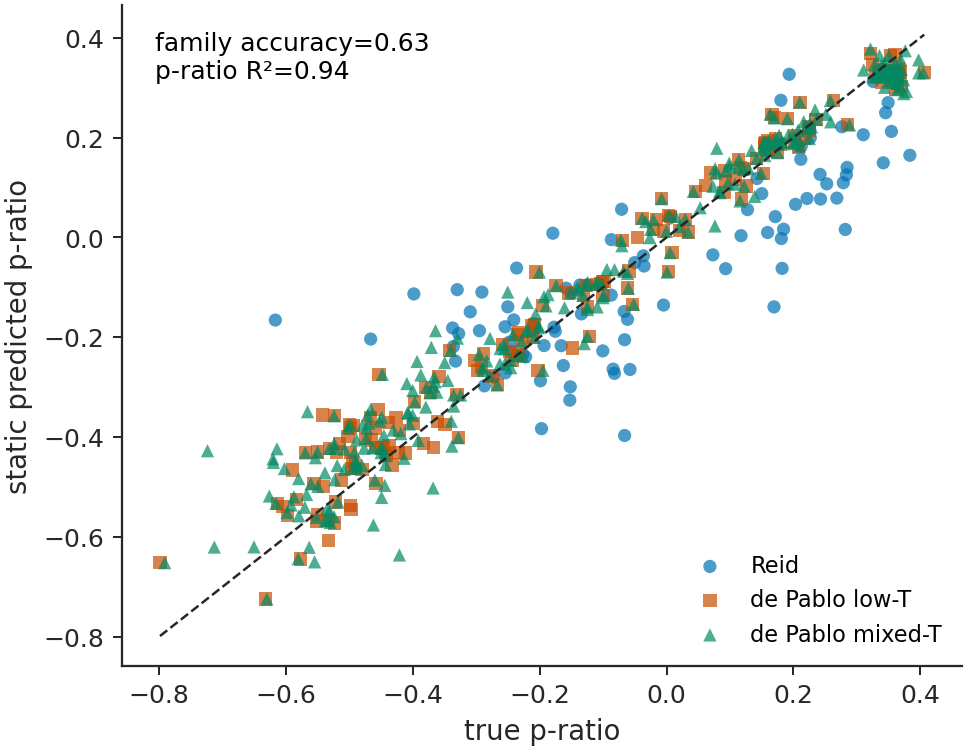

,evaluation_group,classification_accuracy,p_ratio_r2,p_ratio_pearson_r,n_networks
0,combined,0.629,0.936,0.970,569
1,Reid,1.000,0.623,0.806,91
2,de Pablo low-T,0.291,0.971,0.988,189
3,de Pablo mixed-T,0.734,0.960,0.984,289


predicted_dataset,Reid,de Pablo low-T,de Pablo mixed-T
dataset,,,
Reid,1.0,0.00,0.00
de Pablo low-T,0.0,0.29,0.71
de Pablo mixed-T,0.0,0.27,0.73


In [14]:
# The test-time input is only initial z0,z1. Dataset labels are used for calibration and evaluation, never as predictor inputs.
STATIC_FEATURES = ['z0_initial', 'z1_initial']
classifier_train = val[STATIC_FEATURES + ['dataset']].dropna().copy()
classifier_test = test[STATIC_FEATURES + ['dataset', 'sim_idx', 'final_p_ratio']].dropna().copy()
x_mean = classifier_train[STATIC_FEATURES].to_numpy(float).mean(0)
x_std = classifier_train[STATIC_FEATURES].to_numpy(float).std(0).clip(min=1e-12)
x_train = (classifier_train[STATIC_FEATURES].to_numpy(float) - x_mean) / x_std
x_test = (classifier_test[STATIC_FEATURES].to_numpy(float) - x_mean) / x_std
classes = np.asarray(DATASET_LABELS)
targets = np.column_stack([classifier_train.dataset.eq(label).to_numpy(float) for label in classes])
design = np.column_stack([np.ones(len(x_train)), x_train])
classifier_weights = np.linalg.solve(design.T@design + 1e-3*np.eye(design.shape[1]), design.T@targets)
test_design = np.column_stack([np.ones(len(x_test)), x_test])
classifier_test['predicted_dataset'] = classes[np.argmax(test_design@classifier_weights, axis=1)]

family_models = {}
for dataset in DATASET_LABELS:
    family = val[val.dataset.eq(dataset)][STATIC_FEATURES + ['final_p_ratio']].dropna()
    family_x = family[STATIC_FEATURES].to_numpy(float)
    family_mean = family_x.mean(0); family_std = family_x.std(0).clip(min=1e-12)
    family_design = np.column_stack([np.ones(len(family_x)), (family_x-family_mean)/family_std])
    penalty = np.eye(family_design.shape[1]); penalty[0,0] = 0
    weights = np.linalg.solve(family_design.T@family_design + 1e-4*penalty, family_design.T@family.final_p_ratio.to_numpy(float))
    family_models[dataset] = (family_mean, family_std, weights)

predicted_p_ratio = np.empty(len(classifier_test), dtype=float)
for dataset, indices in classifier_test.groupby('predicted_dataset').groups.items():
    family_mean, family_std, weights = family_models[dataset]
    family_x = classifier_test.loc[indices, STATIC_FEATURES].to_numpy(float)
    predicted_p_ratio[classifier_test.index.get_indexer(indices)] = np.column_stack([np.ones(len(indices)), (family_x-family_mean)/family_std])@weights
classifier_test['predicted_p_ratio'] = predicted_p_ratio
classifier_test['correct_family'] = classifier_test.dataset.eq(classifier_test.predicted_dataset)
static_rows = []
for label, group in [('combined', classifier_test), *[(dataset, classifier_test[classifier_test.dataset.eq(dataset)]) for dataset in DATASET_LABELS]]:
    static_rows.append({'evaluation_group': label, 'classification_accuracy': group.correct_family.mean(), 'p_ratio_r2': r2_score(group.final_p_ratio, group.predicted_p_ratio), 'p_ratio_pearson_r': pearson_r(group.final_p_ratio, group.predicted_p_ratio), 'n_networks': len(group)})
static_scores = pd.DataFrame(static_rows)
classifier_test.to_csv(OUTPUT/'static_family_and_pratio_predictions.csv', index=False)
static_scores.to_csv(OUTPUT/'static_family_and_pratio_scores.csv', index=False)
print('Static-only prediction: family inferred from initial latent, followed by its calibrated p-ratio readout.')
fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
for dataset, group in classifier_test.groupby('dataset'):
    key, marker = SOURCE_STYLES[dataset]
    ax.scatter(group.final_p_ratio, group.predicted_p_ratio, s=28, alpha=.7, marker=marker, color=SOURCE_COLORS[dataset], edgecolor='none', label=dataset)
limits = np.r_[classifier_test.final_p_ratio, classifier_test.predicted_p_ratio]; lo, hi = np.nanmin(limits), np.nanmax(limits)
ax.plot([lo,hi], [lo,hi], '--', color=PAPER_COLORS['ink'], lw=1)
combined_static = static_scores.query("evaluation_group == 'combined'").iloc[0]
ax.text(.04,.96,f"family accuracy={combined_static.classification_accuracy:.2f}\np-ratio R²={combined_static.p_ratio_r2:.2f}", transform=ax.transAxes, ha='left', va='top')
style_axes(ax, xlabel='true p-ratio', ylabel='static predicted p-ratio', legend=True)
plt.show(); display(static_scores.round(3))
display(pd.crosstab(classifier_test.dataset, classifier_test.predicted_dataset, normalize='index').round(2))

## Mixed-temperature latent dynamics

Held-out mixed-temperature latent trajectories; colour denotes temperature.


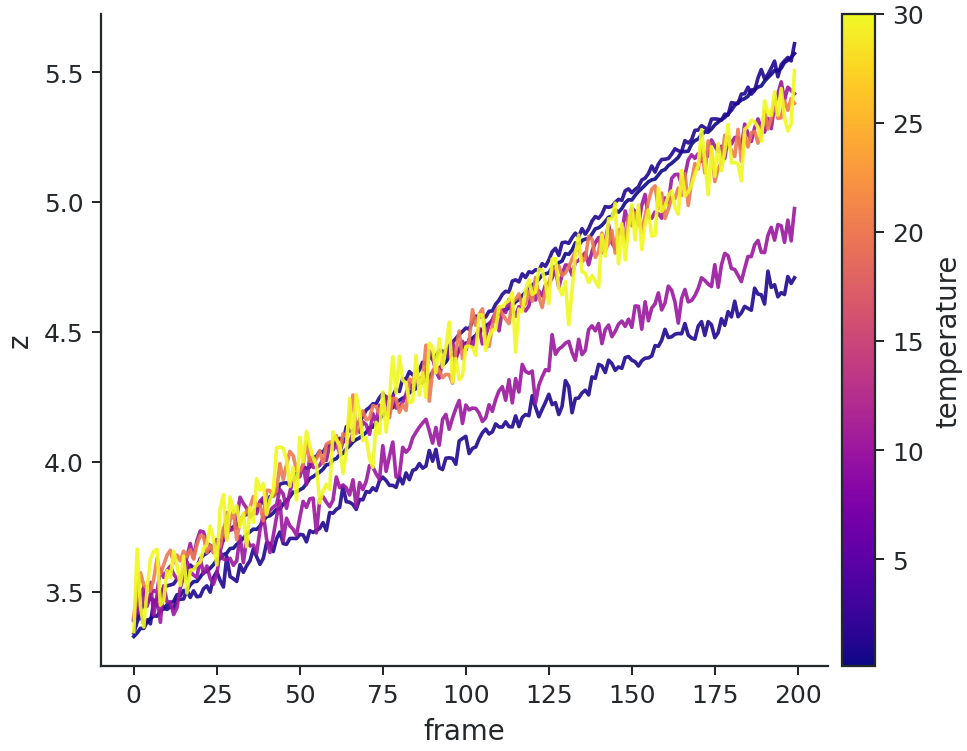

Thermal latent fluctuations versus temperature on held-out mixed-temperature networks.


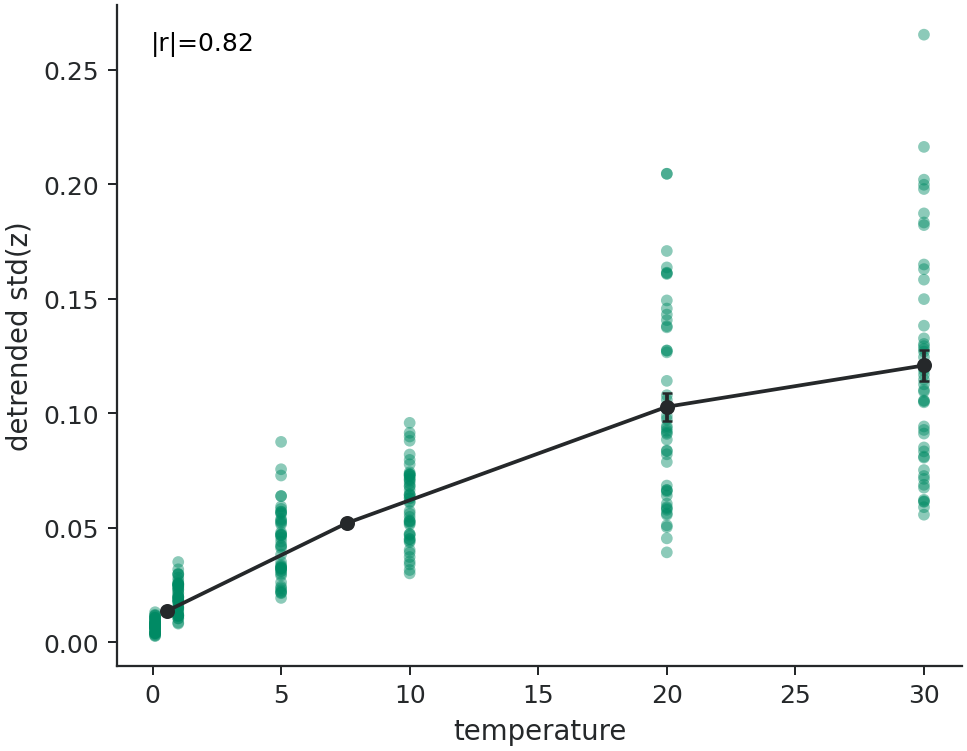

,coordinate,metric,pearson_r,absolute_pearson_r,n_networks
0,z,detrended std,0.816,0.816,289


In [15]:
def mixed_temperature_analysis():
    mixed_label = 'de Pablo mixed-T'
    if mixed_label not in DATASET_LABELS:
        print('Skipping mixed-temperature analysis: that source is not enabled in DATASETS.')
        return pd.DataFrame(columns=['coordinate','metric','pearson_r','absolute_pearson_r','n_networks'])
    mixed_test = test_descriptors[test_descriptors.dataset.eq(mixed_label)].dropna(subset=['temperature']).copy()
    mixed_frames = frame_df.query("split == 'test' and dataset == @mixed_label").copy()
    ordered = mixed_test.sort_values('temperature')
    selected_positions = np.unique(np.linspace(0, len(ordered)-1, min(7, len(ordered)), dtype=int))
    selected_ids = ordered.iloc[selected_positions].sim_idx.to_numpy(int)
    temperature_norm = Normalize(vmin=mixed_test.temperature.min(), vmax=mixed_test.temperature.max())
    temperature_cmap = plt.get_cmap('plasma')
    print('Held-out mixed-temperature latent trajectories; colour denotes temperature.')
    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
    for sim_idx in selected_ids:
        trajectory = mixed_frames[mixed_frames.sim_idx.eq(sim_idx)].sort_values('frame_idx')
        temperature = float(trajectory.temperature.iloc[0])
        ax.plot(trajectory.frame_idx, trajectory['z0'], color=temperature_cmap(temperature_norm(temperature)), lw=1.45, alpha=.9)
    style_axes(ax, xlabel='frame', ylabel='z')
    fig.colorbar(plt.cm.ScalarMappable(norm=temperature_norm, cmap=temperature_cmap), ax=ax, label='temperature', pad=.02)
    plt.show()
    print('Thermal latent fluctuations versus temperature on held-out mixed-temperature networks.')
    metric = 'z0_detrended_std'
    values = mixed_test[['temperature', metric]].dropna()
    r = pearson_r(values.temperature, values[metric])
    rows = [{'coordinate': 'z', 'metric': 'detrended std', 'pearson_r': r, 'absolute_pearson_r': abs(r), 'n_networks': len(values)}]
    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
    ax.scatter(values.temperature, values[metric], s=22, alpha=.45, color=dataset_color('depablo_mixed_temp'), edgecolor='none')
    bins = pd.qcut(values.temperature, q=min(6, values.temperature.nunique()), duplicates='drop')
    summary = values.assign(bin=bins).groupby('bin', observed=True).agg(temperature=('temperature','mean'), mean=(metric,'mean'), sem=(metric,'sem')).reset_index(drop=True)
    ax.errorbar(summary.temperature, summary['mean'], yerr=summary['sem'].fillna(0), color=PAPER_COLORS['ink'], marker='o', lw=1.5, capsize=2)
    ax.text(.04,.96,f'|r|={abs(r):.2f}', transform=ax.transAxes, ha='left', va='top')
    style_axes(ax, xlabel='temperature', ylabel='detrended std(z)')
    plt.show()
    return pd.DataFrame(rows)

fluctuation_correlations = mixed_temperature_analysis()
fluctuation_correlations.to_csv(OUTPUT/'temperature_latent_fluctuation_correlations.csv', index=False)
display(fluctuation_correlations.round(3))

## The shared plane on held-out networks

Held-out shared latent descriptors colored by final p-ratio; marker shape identifies the dataset.


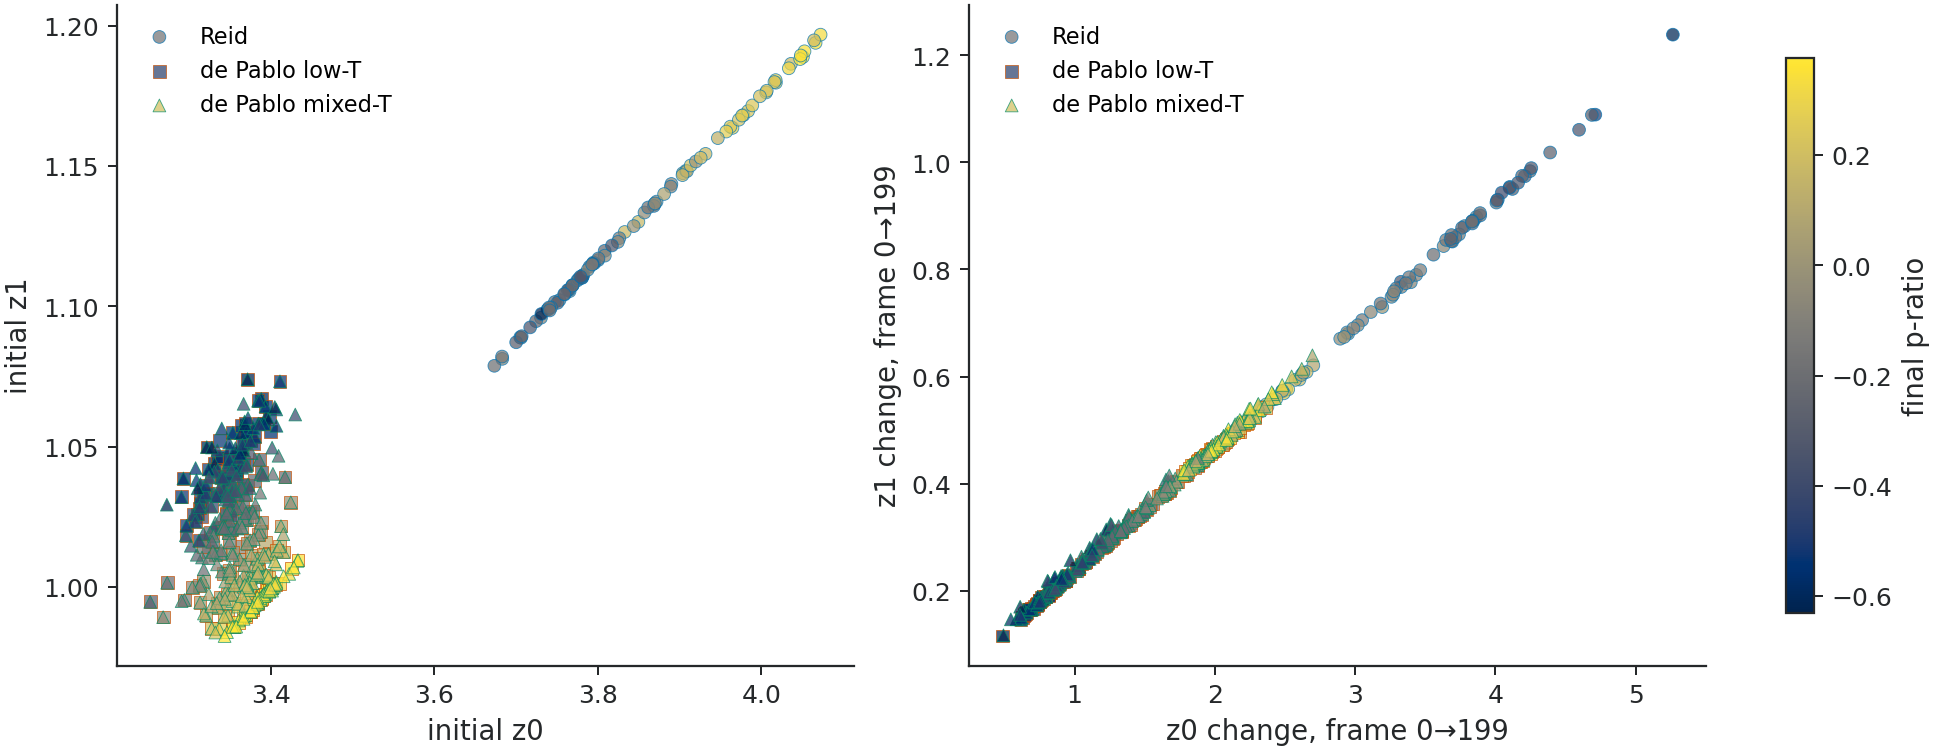

In [16]:
norm=Normalize(vmin=test_descriptors.final_p_ratio.quantile(.01),vmax=test_descriptors.final_p_ratio.quantile(.99))
print('Held-out shared latent descriptors colored by final p-ratio; marker shape identifies the dataset.')
fig,axes=plt.subplots(1,2,figsize=PAPER_WIDE_FIGSIZE,constrained_layout=True)
for ax,(xcol,ycol,xlabel,ylabel) in zip(axes,[('z0_initial','z1_initial','initial z0','initial z1'),('z0_delta','z1_delta','z0 change, frame 0→199','z1 change, frame 0→199')]):
    for dataset,group in test_descriptors.groupby('dataset'):
        key, marker = SOURCE_STYLES[dataset]
        ax.scatter(group[xcol],group[ycol],c=group.final_p_ratio,cmap='cividis',norm=norm,s=26,marker=marker,alpha=.72,edgecolor=SOURCE_COLORS[dataset],linewidth=.35,label=dataset)
    style_axes(ax,xlabel=xlabel,ylabel=ylabel,legend=True)
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap='cividis'),ax=axes,label='final p-ratio',shrink=.84)
plt.show()